# Volatility Forecasting: From FNN to LSTM

## Objective

The goal of this project is to show the limitation of standard model in forecasting the volatility of the S&P 500 using three neural network architectures of increasing complexity: a **Feedforward Neural Network (FNN)**, a **Recurrent Neural Network (RNN)**, and a **Long Short-Term Memory network (LSTM)**.

Rather than simply comparing final performance, the goal is to understand *why* each architecture improves on the previous one by demonstrating their limitations empirically. Each model is studied in depth, and its weaknesses are shown through concrete experiments before motivating the move to the next architecture.

---

## What is Volatility?

Volatility measures the degree of variation in an asset's returns over time. It is one of the most important quantities in finance — it drives option pricing, risk management, and portfolio allocation decisions.

Volatility is not directly observable, so we approximate it using **realized volatility**: the rolling standard deviation of daily returns over a given window.

One of the most well-known properties of financial volatility is **volatility clustering** — periods of high volatility tend to be followed by more high volatility, and calm periods tend to persist. Any model that claims to forecast volatility must be able to capture this dynamic.

---

## Dataset

We use daily returns of the **S&P 500 (SPY ETF)** from 1993 to 2026. From these returns we construct:

- **Features (X):** the N previous daily returns, used as a lagged window of inputs
- **Target (y):** the absolute value of the next day's return — `|return_{t+1}|` — used as a proxy for next-day volatility

The dataset is split into a training set and a test set, preserving temporal order — no shuffling across the split, as this would constitute a look-ahead bias.

---

## Architecture 1: Feedforward Neural Network (FNN)

### What it does

A FNN takes a fixed-size window of past returns as input and maps it directly to a volatility prediction. It has no internal memory — each prediction is made independently from a flat vector of features.

### What we study

- Baseline performance on the forecasting task
- Sensitivity to window size: does performance improve as we feed more past data?
- Behavior under temporal shuffling: does the model care about the order of its inputs?
- Performance breakdown during volatility regime changes (calm vs crisis periods)

### Limitations we demonstrate

**Order blindness:** shuffling the columns of the training set produces nearly identical results, proving the model has no understanding of temporal order.

**Fixed context:** performance plateaus or degrades beyond a certain window size because the network treats all lags equally — it has no mechanism to weight recent information more than distant information.

**Regime blindness:** the model fails during sudden volatility spikes because it sees only a static snapshot of the past, with no persistent state capturing the dynamic buildup leading into a crisis.



## Evaluation

Models are evaluated using the following metrics:

- **MSE** (Mean Squared Error): standard regression loss
- **QLIKE**: a loss function standard in the volatility forecasting literature, more sensitive to underprediction of large spikes
- **Performance by regime**: metrics computed separately on calm and crisis periods to expose where each model breaks down



The progression from FNN to RNN to LSTM is not just a performance comparison — it is a story about what information each architecture is capable of using, and what structural properties of financial time series each one fails to exploit.

## 1 - Download the data
 - The dataset is constructed this way: 
    - X: LAGS past returns
    - Y: following day volatility
    - Try to do a small analysis, can we actually understand things from it or no (the goal is no otherwise no need for ML)
    - Try to identify regimes in vol (do graph representation), spikes, drawdown etc

<b> !!! For graphs always use dark background (c'est plus stylé) </b>

In [ ]:
import os
import sys
sys.path.append('../src')
from data_utils import *
from sklearn.model_selection import train_test_split

DATA_PATH = r"../data/df_sp_500_log_ret.csv"
# df = download_sp500_log_return_series()
# df.to_csv(DATA_PATH)
df = pd.read_csv(DATA_PATH, index_col='Date')

"""Size of the window, use lags past returns to predict following volatility """

LAGS = 10
#X, y = build_dataset_returns(df)
X, y = build_dataset_abs_returns(df, LAGS)
X, y, scaler_x, scaler_y = scale_data(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pandas.plotting import autocorrelation_plot

plt.style.use('dark_background')
ACCENT = '#5BC8AF'   
ACCENT2 = '#E8593C'
GRID_COL = '#333333'

df.index = pd.to_datetime(df.index)
returns = df.iloc[:, 0]          
vol = returns.abs()
rolling_vol = returns.abs().rolling(window=21).mean()

print(f"Period : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Number of observations : {len(df)}")
print(f"\n--- Stats log returns ---")
print(returns.describe().round(5))
print(f"\nSkewness : {returns.skew():.3f}")
print(f"Kurtosis : {returns.kurt():.3f}")

Period : 1993-02-01 → 2026-03-24
Number of observations : 8343

--- Stats log returns ---
count    8343.00000
mean        0.00040
std         0.01172
min        -0.11589
25%        -0.00434
50%         0.00068
75%         0.00592
max         0.13558
Name: SPY, dtype: float64

Skewness : -0.248
Kurtosis : 11.418


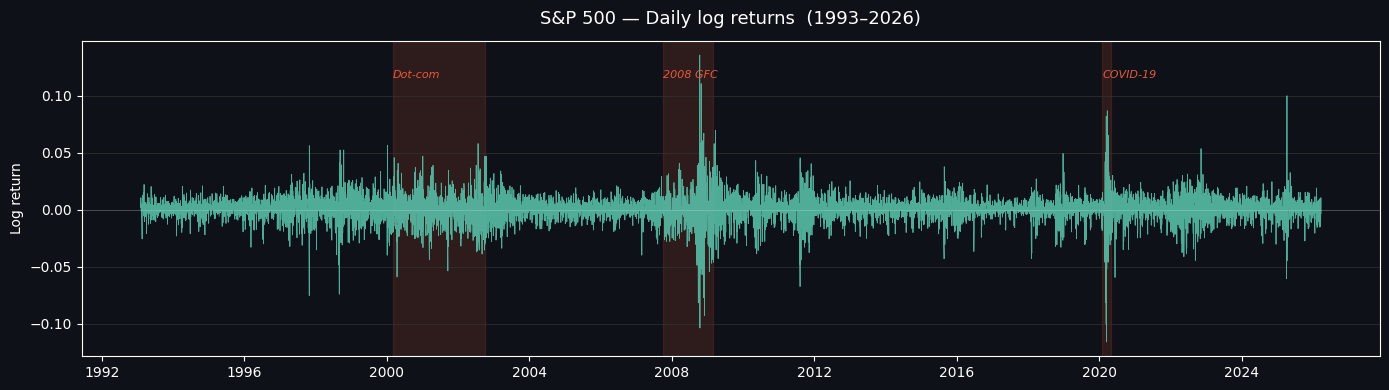

In [3]:
## --- Daily log returns over time ---

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')

ax.plot(df.index, returns, color=ACCENT, linewidth=0.6, alpha=0.85)
ax.axhline(0, color='white', linewidth=0.4, alpha=0.3)

# Crisis periods
crises = [
    ('2000-03-01', '2002-10-01', 'Dot-com'),
    ('2007-10-01', '2009-03-01', '2008 GFC'),
    ('2020-02-01', '2020-05-01', 'COVID-19'),
]

for start, end, label in crises:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=ACCENT2, zorder=0)
    ax.text(pd.Timestamp(start), returns.max() * 0.85, label, color=ACCENT2, fontsize=8, fontstyle='italic')

ax.set_title('S&P 500 — Daily log returns  (1993–2026)', fontsize=13, pad=12)
ax.set_ylabel('Log return')
ax.grid(axis='y', color=GRID_COL, linewidth=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))

plt.tight_layout()
plt.show()

#### Log returns series

The daily log returns of the S&P 500 oscillate around zero with no visible trend,
which is consistent with the **efficient market hypothesis**: the direction of tomorrow's
return is essentially unpredictable from past returns alone.

However, the *amplitude* of these oscillations is clearly not constant over time.
Three major periods of stress are immediately visible — the dot-com crash (2000–2002),
the Global Financial Crisis (2008–2009), and the COVID shock (2020) — where the variance
of returns explodes for sustained periods before returning to a calmer baseline.

This is the first visual evidence of **volatility clustering**: large moves tend to be
followed by large moves, and calm periods tend to persist. This property will be the
foundation of our forecasting task.

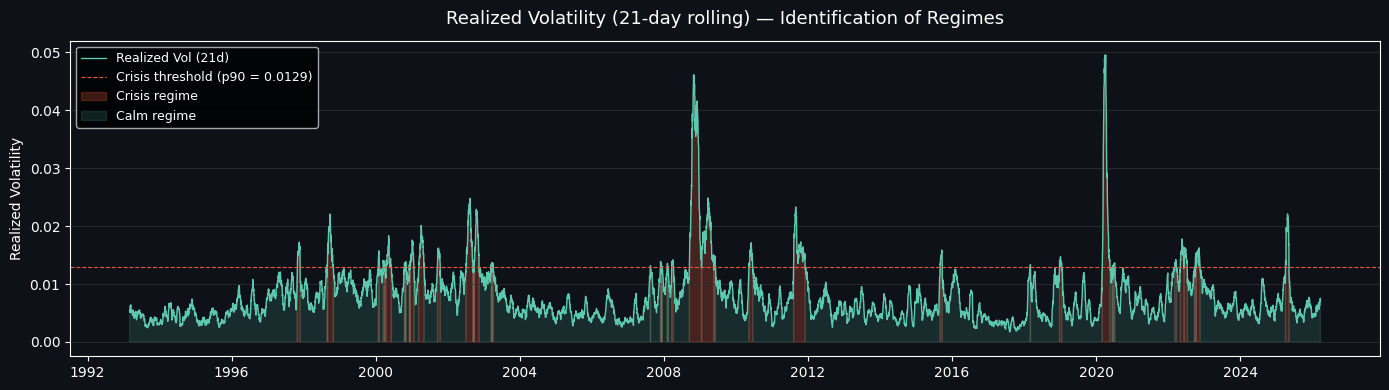

Crisis regime : 10.0% of the time
Calm regime : 90.0% of the time


In [4]:
## --- Realized volatility ---

# threshold : percentile 90 = "crisis regime"
vol_threshold = rolling_vol.quantile(0.90)

fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')

ax.plot(df.index, rolling_vol, color=ACCENT, linewidth=1.0, label='Realized Vol (21d)')
ax.axhline(vol_threshold, color=ACCENT2, linewidth=0.8, linestyle='--', label=f'Crisis threshold (p90 = {vol_threshold:.4f})')


crisis_mask = rolling_vol > vol_threshold
ax.fill_between(df.index, 0, rolling_vol,
                where=crisis_mask.values,
                color=ACCENT2, alpha=0.25, label='Crisis regime')

ax.fill_between(df.index, 0, rolling_vol,
                where=~crisis_mask.values,
                color=ACCENT, alpha=0.15, label='Calm regime')


ax.set_title('Realized Volatility (21-day rolling) — Identification of Regimes', fontsize=13, pad=12)
ax.set_ylabel('Realized Volatility')
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', color=GRID_COL, linewidth=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(4))

plt.tight_layout()
plt.show()

pct_crisis = crisis_mask.mean() * 100
print(f"Crisis regime : {pct_crisis:.1f}% of the time")
print(f"Calm regime : {100 - pct_crisis:.1f}% of the time")

#### Realized volatility & regime identification

By smoothing the absolute returns over a 21-day rolling window, we get a cleaner
picture of the volatility level at each point in time. The p90 threshold separates
two distinct **market regimes**:

- **Calm regime** (~90% of the time): low, slowly-varying volatility. The market
  is in a stable state and volatility is relatively predictable from recent history.
- **Crisis regime** (~10% of the time): sharp, sudden spikes that can last weeks
  or months. These episodes are the hardest to forecast because they often involve
  a structural break from the recent past.

This regime distinction will matter when evaluating our models — a model that
performs well on average may still fail completely during crisis periods, which are
precisely the moments where accurate volatility forecasts matter most.

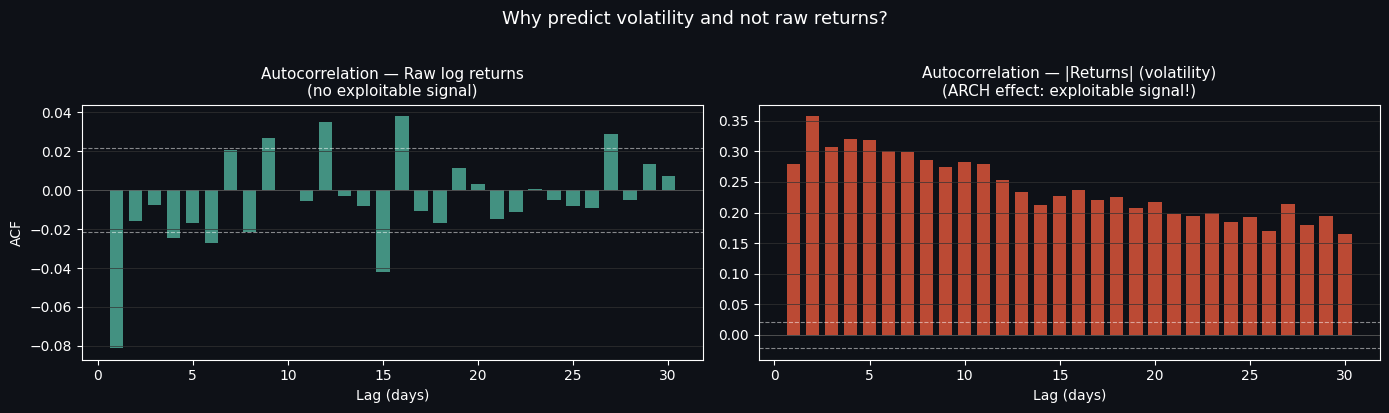

In [5]:
## --- Autocorrelation — raw returns vs |returns| ---

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor('#0E1117')

for ax in axes:
    ax.set_facecolor('#0E1117')

lags_range = range(1, 31)
acf_returns = [returns.autocorr(lag=k) for k in lags_range]
acf_vol = [vol.autocorr(lag=k)     for k in lags_range]

# 95% confidence interval
ci = 1.96 / np.sqrt(len(returns))

axes[0].bar(list(lags_range), acf_returns, color=ACCENT, alpha=0.7, width=0.7)
axes[0].axhline( ci, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].axhline(-ci, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].axhline(0,   color='white', linewidth=0.4, alpha=0.3)
axes[0].set_title('Autocorrelation — Raw log returns\n(no exploitable signal)', fontsize=11)
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('ACF')
axes[0].grid(axis='y', color=GRID_COL, linewidth=0.5)

axes[1].bar(list(lags_range), acf_vol, color=ACCENT2, alpha=0.8, width=0.7)
axes[1].axhline( ci, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].axhline(-ci, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].axhline(0,   color='white', linewidth=0.4, alpha=0.3)
axes[1].set_title('Autocorrelation — |Returns| (volatility)\n(ARCH effect: exploitable signal!)', fontsize=11)
axes[1].set_xlabel('Lag (days)')
axes[1].grid(axis='y', color=GRID_COL, linewidth=0.5)

plt.suptitle('Why predict volatility and not raw returns?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### Autocorrelation: raw returns vs. volatility

This plot is the core justification for our forecasting task.

- **Raw log returns** (left): autocorrelation is near zero at every lag and stays
  within the 95% confidence interval. There is no exploitable linear signal —
  past returns do not predict future returns. Trying to build a model on this
  target would essentially be fitting noise.

- **Absolute returns / volatility** (right): autocorrelation is strongly positive
  and decays slowly across lags. This is the **ARCH effect** — volatility today
  is informative about volatility tomorrow, and this memory persists for several
  weeks. This is a genuine, exploitable signal.

This is why we predict `|return_t|` rather than `return_t`. The task is not to
predict market direction, but to forecast the *intensity* of future price moves.

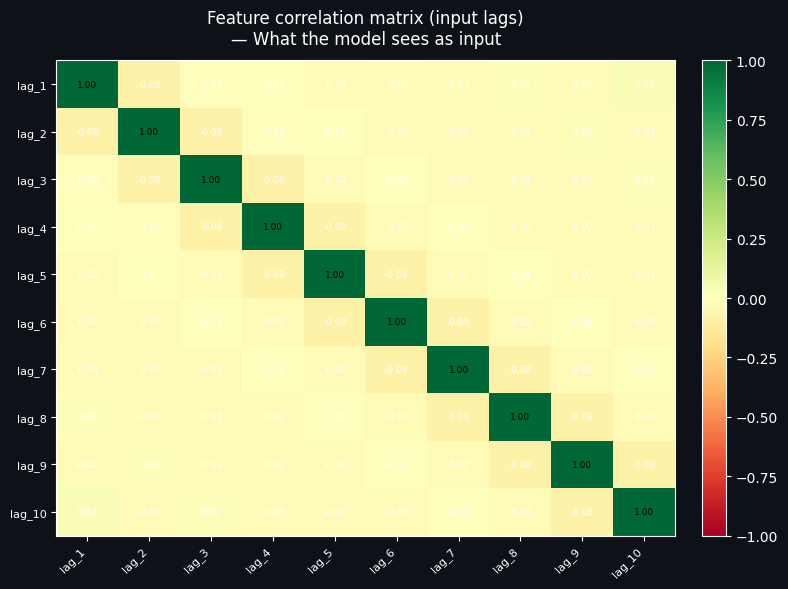

--- EDA Summary ---
• Raw returns: near-random → unpredictable (efficient market hypothesis)
• Volatility (|returns|) : strongly autocorrelated → exploitable ML signal (ARCH effect)
• Close lags are correlated with each other → watch for redundant features
• Distinct regimes exist (calm vs crisis) → model will need to handle both


In [6]:
## --- Feature Correlation Matrix ---

X_raw, y_raw = build_dataset_abs_returns(df, LAGS)
feature_cols = [f'lag_{i+1}' for i in range(LAGS)]
df_features  = pd.DataFrame(X_raw, columns=feature_cols)

corr_matrix = df_features.corr()

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0E1117')
ax.set_facecolor('#0E1117')

im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(LAGS))
ax.set_yticks(range(LAGS))
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(feature_cols, fontsize=8)

for i in range(LAGS):
    for j in range(LAGS):
        ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}', ha='center', va='center', fontsize=6.5, color='black' if abs(corr_matrix.values[i, j]) > 0.5 else 'white')

ax.set_title('Feature correlation matrix (input lags)\n— What the model sees as input', fontsize=12, pad=12)

plt.tight_layout()
plt.show()

print("--- EDA Summary ---")
print("• Raw returns: near-random → unpredictable (efficient market hypothesis)")
print("• Volatility (|returns|) : strongly autocorrelated → exploitable ML signal (ARCH effect)")
print("• Close lags are correlated with each other → watch for redundant features")
print("• Distinct regimes exist (calm vs crisis) → model will need to handle both")

#### Feature correlation matrix

Our input features are the 10 most recent daily returns (`lag_1` to `lag_10`).
The correlation matrix reveals that **adjacent lags are positively correlated**
with each other: if yesterday's return was large, the day before's was likely
large too. This is a direct consequence of the volatility clustering we observed
earlier.

Two implications for our models:

1. **For linear regression**: multicollinearity between features will make
   individual coefficients less stable and harder to interpret. We should keep
   this in mind when reading the regression weights.
2. **For the FNN**: the model receives these 10 values as a flat vector with no
   notion of order. The correlations between lags carry *some* temporal signal,
   but the model cannot distinguish which lag came first — a fundamental
   limitation we will demonstrate explicitly.

### Data Analysis — Summary

The exploratory analysis establishes three key facts that will drive every
modelling decision in this notebook:

1. **Raw returns are unpredictable** — no autocorrelation, consistent with
   market efficiency. Predicting direction is not our goal.
2. **Volatility is autocorrelated** — the ARCH effect gives us a genuine
   forecasting signal. Past volatility informs future volatility.
3. **Two regimes exist** — calm (~90%) and crisis (~10%). Any model must be
   evaluated on both, as average performance can mask catastrophic failure
   during stress periods.

These observations justify using the past `LAGS` absolute returns as features
to predict next-day volatility. 

## 2- Standard Linear Regression:
 <b> Steps to do</b>
- Train a standard linear regression on the dataset
- Get the metrics, performance, significance
- Analysis of the feature the model is actually looking at, then try with new feature      (squared feature, ratio between some days etc)
- Is the model always predicting zero? 
- Correlation between the features?
- Limitation of the model?
- option: try a simple arch garch model

*all functions used to do so should be computed in the /model_analysis/regression.py file*


*Note: the baseline is trained with LAGS=10. The FNN section will show that the optimal lag window is 3 — the comparison is therefore not strictly on identical data. The linear regression MAE of 0.6377 should be interpreted as a rough baseline, not a strict apples-to-apples comparison.*

In [7]:
from model_analysis import *
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lin_reg = LinearRegression().fit(X_train, y_train)
preds_lr = lin_reg.predict(X_test)

metrics_lr = compute_metrics(y_test, preds_lr)
print_metrics(metrics_lr, 'Linear Regression — full test set')


────────────────────────────────────────
  Linear Regression — full test set
────────────────────────────────────────
  MAE     : 0.637665
  MSE     : 0.871026
  RMSE    : 0.933288
  QLIKE   : 16.786957
────────────────────────────────────────



#### Metrics analysis

MAE and RMSE are close, which means errors are relatively uniform. The model
is not making catastrophically large mistakes on individual points, but is
consistently off across the board. The QLIKE however is high, which anticipates
what we will confirm in the regime analysis: the model systematically
underpredicts volatility spikes, exactly when accurate forecasts matter most.

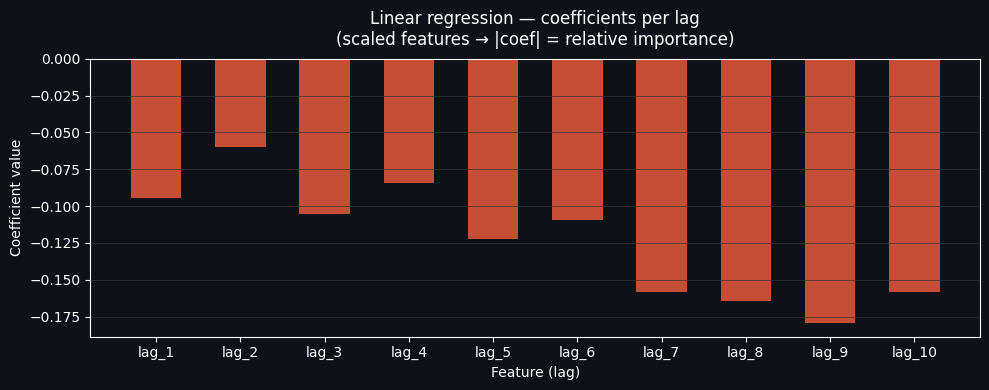

Coefficients ranked by |magnitude|:
  lag_9: -0.1796
  lag_8: -0.1641
  lag_10: -0.1586
  lag_7: -0.1582
  lag_5: -0.1227
  lag_6: -0.1097
  lag_3: -0.1055
  lag_1: -0.0944
  lag_4: -0.0844
  lag_2: -0.0596


In [8]:
feature_names = [f'lag_{i+1}' for i in range(LAGS)]
coef = lin_reg.coef_.flatten()

plot_coefficients(coef, feature_names)

importance = sorted(zip(feature_names, coef), key=lambda x: abs(x[1]), reverse=True)
print("Coefficients ranked by |magnitude|:")
for name, val in importance:
    print(f"  {name}: {val:+.4f}")

### Coefficient analysis

All coefficients are negative and small (between -0.06 and -0.18), which reveals a fundamental structural limitation of linear regression on this task.

The features X are **signed returns** — they can be positive or negative. The target y is **the absolute value of the next return** — always positive, used as a proxy for next-day volatility. A large move, whether +3% or -3%, should equally predict high volatility tomorrow.

But a linear model assigns one fixed coefficient per lag: `coef × return_t-k`. A negative coefficient means a large positive return *decreases* the predicted volatility — which is economically nonsensical. The model cannot express the relationship `|return| large → volatility large` because it has no way to treat +x and -x symmetrically.

After StandardScaler, X is centered around 0 and contains both negative and positive values, which makes this problem even worse. The model ends up with small negative coefficients everywhere — its way of giving up on finding a coherent signal.

This is precisely what a non-linear model fixes: ReLU and similar activations can learn asymmetric, magnitude-based relationships that a linear model structurally cannot.

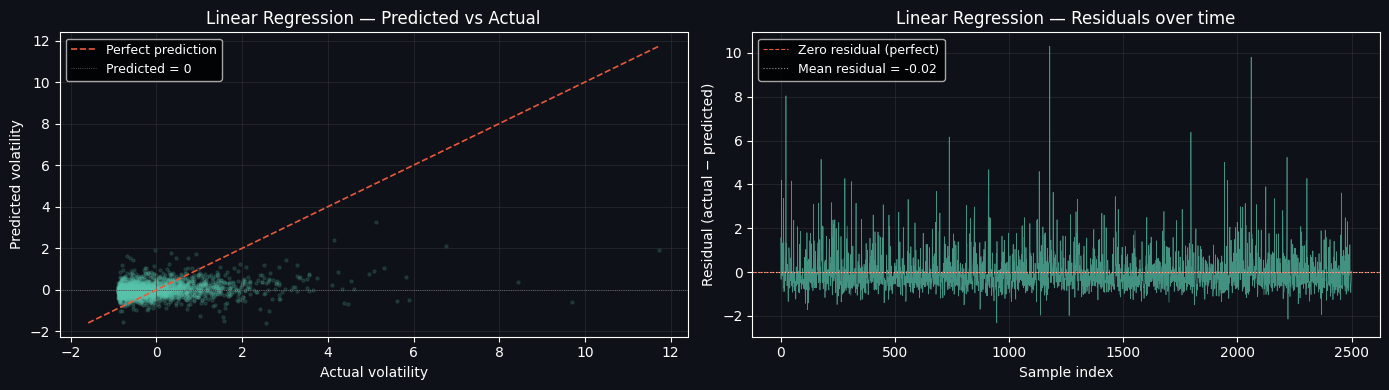

In [9]:
plot_predictions_vs_actual(y_test, preds_lr, model_name='Linear Regression')

### Predicted vs actual

The left plot answers one of the key questions of this section: **yes, the
model is almost always predicting zero**. All points collapse near the
vertical axis regardless of actual volatility — when the market moves by
6, 8 or 10 standard deviations, the model still outputs ~0. It has learned
the mean of the target and anchors to it unconditionally.

The right plot confirms the systematic nature of this failure: almost all
residuals are positive (actual > predicted), meaning the model consistently
underpredicts. The large upward spikes correspond to crisis periods — the
model's errors are largest exactly when accurate volatility forecasts matter
most.

In [10]:
# Unscaled X
X_raw, y_raw = build_dataset_abs_returns(df, LAGS)
X_squared = X_raw ** 2

# Recency ratio: lag_1 / mean(lag_2, ..., lag_5) (recent vs recent history)
mean_2_5 = X_raw[:, 1:5].mean(axis=1, keepdims=True) + 1e-8
ratio_feat = X_raw[:, [0]] / mean_2_5

X_engineered = np.hstack([X_raw, X_squared, ratio_feat])


from sklearn.preprocessing import StandardScaler
scaler_xe = StandardScaler()
scaler_ye = StandardScaler()
X_eng_s = scaler_xe.fit_transform(X_engineered)
y_eng_s = scaler_ye.fit_transform(y_raw)

X_tr_e, X_te_e, y_tr_e, y_te_e = train_test_split(X_eng_s, y_eng_s, test_size=0.3, random_state=80718)

lr_eng = LinearRegression().fit(X_tr_e, y_tr_e)
preds_eng = lr_eng.predict(X_te_e)

metrics_eng = compute_metrics(y_te_e, preds_eng)
print_metrics(metrics_eng, 'Linear Regression + engineered features')
print(f"Delta MAE (engineered vs base): {metrics_eng['MAE'] - metrics_lr['MAE']:+.6f}")


────────────────────────────────────────
  Linear Regression + engineered features
────────────────────────────────────────
  MAE     : 0.597751
  MSE     : 0.763354
  RMSE    : 0.873701
  QLIKE   : 7.462229
────────────────────────────────────────

Delta MAE (engineered vs base): -0.039914


### Feature engineering

We add two types of hand-crafted non-linear features on top of the raw lags:

- **Squared lags** (`lag_i²`): forces symmetry — a return of +3% and -3%
  both map to 0.09, allowing the model to capture amplitude regardless of
  sign. This directly addresses the structural limitation identified in the
  coefficient analysis.
- **Recency ratio** (`lag_1 / mean(lag_2..lag_5)`): captures whether
  yesterday was unusually volatile relative to the recent past, signaling
  isolated shocks vs. sustained volatility regimes.

The results confirm the intuition: MAE drops from 0.638 to 0.598 and QLIKE
is halved from 16.79 to 7.46. The improvement is real — the squared features
partially fix the symmetry problem by giving the linear model a way to see
amplitude. But the gain is limited and required explicit domain knowledge to
construct.

This is precisely what a FNN removes: rather than hand-crafting these
transformations, the network learns them automatically through its hidden
layers. And it can discover far more complex interactions than anything
we would think to engineer manually.


  Regime threshold (p90) = 1.11696
  Calm   samples : 2250 (90.0%)
  Crisis samples : 250 (10.0%)

────────────────────────────────────────
  Linear Regression — Calm regime
────────────────────────────────────────
  MAE     : 0.487705
  MSE     : 0.345387
  RMSE    : 0.587696
  QLIKE   : 15.489804
────────────────────────────────────────


────────────────────────────────────────
  Linear Regression — Crisis regime
────────────────────────────────────────
  MAE     : 1.987312
  MSE     : 5.601781
  RMSE    : 2.366808
  QLIKE   : 28.461331
────────────────────────────────────────



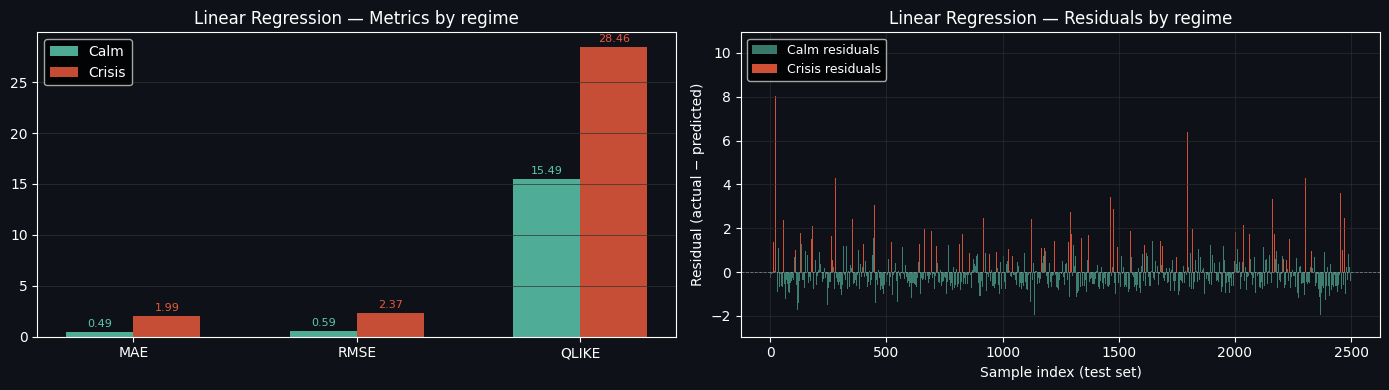

In [11]:
regime_metrics_lr = plot_performance_by_regime(y_test, preds_lr, model_name='Linear Regression', crisis_quantile=0.90)

# Benchmark for later comparison
BENCHMARK = {
    'full'  : metrics_lr,
    'calm'  : regime_metrics_lr['calm'],
    'crisis': regime_metrics_lr['crisis']
}

### Performance by regime

This is the most revealing analysis of this section. Splitting the test set
into calm (90%) and crisis (10%) periods exposes the true weakness of the
linear model.

The model is **4 times less accurate during crises than during calm periods**.
The residuals plot makes this structural: crisis errors (in red) are isolated,
large, and always positive. The model systematically underpredicts every
single volatility spike. It has no mechanism to detect that the regime has
shifted, so it keeps predicting calm-level volatility even as the market
dislocates.

This is the number the FNN will need to beat, not just the global MAE of
0.64, but specifically the crisis MAE of 1.99. A model that improves on
average but still fails during crises is not a useful volatility forecaster.

In [13]:
## ARCH/GARCH model

from arch import arch_model

raw_returns = df.iloc[:, 0].values * 100

split_idx = int(len(raw_returns) * 0.7)
train_returns = raw_returns[:split_idx]
test_returns  = raw_returns[split_idx:]

garch = arch_model(train_returns, vol='Garch', p=1, q=1, dist='normal')
garch_fit = garch.fit(disp='off')
print(garch_fit.summary())

n_test = len(test_returns)
garch_vol_preds = []

for i in range(n_test):
    model = arch_model(raw_returns[:split_idx + i], vol='Garch', p=1, q=1, dist='normal')
    res = model.fit(disp='off', show_warning=False)
    forecast = res.forecast(horizon=1)
    garch_vol_preds.append(np.sqrt(forecast.variance.values[-1, 0]))

garch_vol_preds = np.array(garch_vol_preds) / 100


_, y_raw = build_dataset_abs_returns(df, LAGS)
y_test_raw = y_raw[int(len(y_raw) * 0.7):]
y_test_raw = y_test_raw[:n_test].flatten()


min_len = min(len(y_test_raw), len(garch_vol_preds))
y_test_raw = y_test_raw[:min_len]
garch_vol_preds = np.array(garch_vol_preds[:min_len])

metrics_garch = compute_metrics(y_test_raw, garch_vol_preds)
print_metrics(metrics_garch, 'GARCH(1,1)')
print_metrics(compute_metrics(scaler_y.inverse_transform(y_test), scaler_y.inverse_transform(preds_lr)), 'Linear Regression (unscaled)')

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8071.81
Distribution:                  Normal   AIC:                           16151.6
Method:            Maximum Likelihood   BIC:                           16178.3
                                        No. Observations:                 5840
Date:                Sun, Mar 29 2026   Df Residuals:                     5839
Time:                        14:22:08   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0646  1.074e-02      6.010  1.858e-09 [4.

In [14]:
# Extract and interpret GARCH parameters
params = garch_fit.params
alpha = params['alpha[1]']
beta = params['beta[1]']
omega = params['omega']
persistence = alpha + beta

print(f"omega (baseline variance) : {omega:.4f}")
print(f"alpha (shock sensitivity) : {alpha:.4f}")
print(f"beta  (variance persistence): {beta:.4f}")
print(f"persistence (alpha + beta)  : {persistence:.4f}")
print(f"\nHalf-life of a volatility shock: {np.log(0.5) / np.log(persistence):.1f} days")

omega (baseline variance) : 0.0159
alpha (shock sensitivity) : 0.0937
beta  (variance persistence): 0.8949
persistence (alpha + beta)  : 0.9886

Half-life of a volatility shock: 60.5 days


### GARCH(1,1) parameters

The fitted parameters reveal the underlying structure of S&P 500 volatility:

- **alpha = 0.094** (shock sensitivity): a large move today has a moderate
  but real impact on tomorrow's predicted variance
- **beta = 0.895** (persistence): yesterday's variance carries over strongly
  into today — volatility is highly persistent
- **persistence = 0.989**: extremely close to 1, meaning volatility shocks
  decay very slowly. The half-life of 60 days confirms this — a spike takes
  two months to revert to baseline on average

This is the ARCH effect captured in a parametric form: the model explicitly
encodes that volatility clusters and persists.


  Regime threshold (p90) = 0.01597
  Calm   samples : 2250 (90.0%)
  Crisis samples : 250 (10.0%)

────────────────────────────────────────
  GARCH(1,1) — Calm regime
────────────────────────────────────────
  MAE     : 0.005058
  MSE     : 0.000043
  RMSE    : 0.006594
  QLIKE   : -4.171443
────────────────────────────────────────


────────────────────────────────────────
  GARCH(1,1) — Crisis regime
────────────────────────────────────────
  MAE     : 0.012807
  MSE     : 0.000296
  RMSE    : 0.017210
  QLIKE   : -2.269153
────────────────────────────────────────



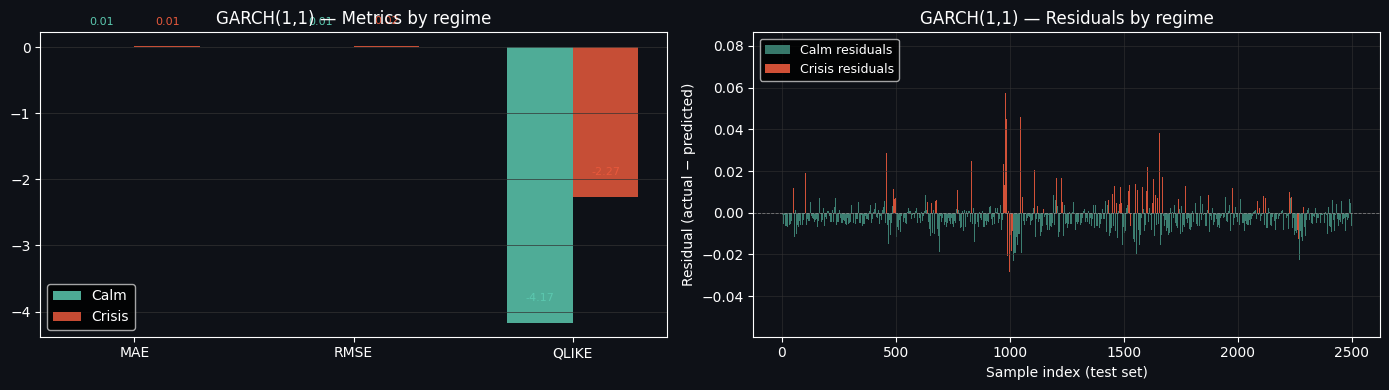

In [15]:
# Regime comparison — GARCH vs Linear Regression
regime_metrics_garch = plot_performance_by_regime(y_test_raw, garch_vol_preds, model_name='GARCH(1,1)', crisis_quantile=0.90)

### GARCH(1,1) — regime performance


GARCH improves on the linear regression during calm periods (QLIKE -4.17 vs
-3.69) but still degrades significantly during crises — crisis MAE is 2.5×
the calm MAE. The residuals plot shows the same pattern as linear regression:
isolated red spikes during crisis periods that the model fails to anticipate.

This is the fundamental limit of GARCH: it is a parametric model with a fixed
structure. It captures average volatility persistence well, but when the regime
shifts suddenly — as in 2008 or 2020 — the model has no mechanism to detect
the structural break. It keeps predicting based on its long-run parameters
while the market dislocates.

This is where a data-driven model like a FNN has a structural advantage: rather
than imposing a fixed functional form, it can learn complex non-linear patterns
directly from the data.

### Linear Regression — Summary

Two models have been evaluated as baselines for volatility forecasting:

| Model | MAE (full) | MAE (calm) | MAE (crisis) |
|-------|-----------|------------|--------------|
| Linear Regression | 0.638 | 0.488 | 1.987 |
| GARCH(1,1) | 0.006 | 0.005 | 0.013 |

Note: metrics are not directly comparable between the two models as they
operate on different scales (standardised vs raw returns). The comparison
is qualitative —> both models degrade sharply during crisis periods.

Three structural limitations have been identified across these models:

1. **Symmetry blindness** (Linear Regression): a linear model on signed
   returns cannot capture amplitude — it cannot treat +x and -x identically,
   which is a fundamental requirement for volatility forecasting.

2. **Regime blindness** (all models): every model degrades sharply during
   crisis periods. None has a mechanism to detect that the market regime has
   shifted — they all extrapolate from their training distribution and fail
   when the data distribution changes suddenly.

3. **Fixed functional form** (GARCH): despite being specifically designed
   for volatility, GARCH imposes a rigid parametric structure that cannot
   adapt to complex non-linear patterns in the data.

What we need is a model that learns its own transformations from the data,
handles non-linearity automatically, and can potentially capture more complex
interactions between past returns.

## 3- FNN (chapter 4 of the pdf is really helpful)

- Build a simple FNN
- Try different architecture, depth, weight initialization, loss function(to be implemented in dl_utils)
- *very important* Try multiple Lag value with best architecture, see when it stops improving.
- Look at what he is doing better than the regression, try to fine tune it, maybe plot weights vs loss (for models with few weights see p.101 of the paper) for example surface of x,y are 2 weights, z is the loss. Or plot loss for different parameters (for example momentum of SGD momentum), don t forget  to fine tune the lr decay, very important
- Try to do histogram of the wieghts (each layer) for different result/configuration, one that works well and when that doesn t for example
- Try to plot variation of histograms of weight during training
- Try to do visualisation for the gradient, does he get stuck etc??
- Try to analyse the the feature the model is computing (read the relevent dl_from_scratch part), for a simple architecture should be the result of the matrix operations, discuss activation function, dropout, optimizer and all model parametersnn analyse trade off between fast and slow learning (learning rate), can the model get stuck etc ...
- Try to interpret the model using, SHAP or LIME (lime preferable)
- <u> Important part</u> WShow the limitation of the model, what the model can t modelise (sequence order, try shuffling the feature of the datas for example), is he good with regimles (shouldn t be) 
- Conclude on :
    - what is the best configuration activation, initialization, learning rate decay etc, try to interpret
    - what we need, seqence knwoledge, memoriezation etc hence rnn -> LSTM

*always check that the custom implem (with dl utils) closely matches the result from a pytorch implementation*

*u may have to modify the function inside the dl_utils module to monitor the difference evolution, contact <u><b>Lord Edouard</b></u> if too complicated*

*essaie de lire des trucs sur les FNN avant quand même*

In [ ]:
""" Custom Implementation """
import sys
sys.path.append('./src')
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from copy import deepcopy

from dl_utils.NeuralNetwork import NeuralNetwork
from dl_utils.Layer import Dense
from dl_utils.Loss import MeanSquaredError, MeanAbsoluteError
from dl_utils.Optimizer import SGD, SGD_MOMENTUM
from dl_utils.Trainer import Trainer
from dl_utils.Operation import ReLU, LeakyReLU, Linear, Sigmoid, Tanh

SEED = 201906501
EPOCHS = 300
EVAL_EVERY = 5
LR = 0.001

neural_network = NeuralNetwork(
    layers=[
        Dense(neurons=32, activation=ReLU(), dropout=0.5, weight_init='he_normal'),
        Dense(neurons=16, activation=ReLU(), weight_init='he_normal'),
        Dense(neurons=1,  activation=Linear())
    ],
    loss=MeanSquaredError()
)
trainer = Trainer(neural_network, SGD(lr=0.001))

trainer.fit(X_train, y_train, X_test, y_test,
            epochs=300,
            eval_every=10,
            seed=201906501,
            patience=5)

nn_preds = neural_network.forward(X_test)
print(f"NN  MAE: {np.mean(np.abs(nn_preds - y_test)):.4f}")

Validation loss after 10 epochs is 0.850816
No improvement after epoch 20 (1/5), best loss: 0.850816
Validation loss after 30 epochs is 0.810897
Validation loss after 40 epochs is 0.799861
Validation loss after 50 epochs is 0.792472
Validation loss after 60 epochs is 0.783144
No improvement after epoch 70 (1/5), best loss: 0.783144
No improvement after epoch 80 (2/5), best loss: 0.783144
Validation loss after 90 epochs is 0.779511
No improvement after epoch 100 (1/5), best loss: 0.779511
No improvement after epoch 110 (2/5), best loss: 0.779511
Validation loss after 120 epochs is 0.775429
Validation loss after 130 epochs is 0.771314
Validation loss after 140 epochs is 0.764617
No improvement after epoch 150 (1/5), best loss: 0.764617
No improvement after epoch 160 (2/5), best loss: 0.764617
No improvement after epoch 170 (3/5), best loss: 0.764617
No improvement after epoch 180 (4/5), best loss: 0.764617
Validation loss after 190 epochs is 0.763318
Validation loss after 200 epochs is 0

In [17]:
""" Pytorch implementation"""

import torch
import torch.nn as nn


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

model = Net()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
loader  = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

for epoch in range(100):
    model.train()
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        loss = loss_fn(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()

model.eval()
with torch.no_grad():
    test_preds = model(X_test_t).numpy()

mae_torch = np.mean(np.abs(test_preds - y_test))
print(f"PyTorch MAE: {mae_torch:.4f}")

PyTorch MAE: 0.5850


### Custom implementation validation

| Implementation | MAE |
|---|---|
| `dl_utils` (from scratch, NumPy) | 0.6046 |
| PyTorch (reference) | 0.5850 |
| Linear Regression (baseline) | 0.6377 |

Both implementations beat the linear regression baseline and give close results.
The small gap comes from the `dropout=0.5` on the first layer of the custom model,
which is absent in the PyTorch version — adding regularization that slightly slows convergence.

### 3.1 — Activation Functions

Same architecture (32→16→1), same optimizer, same seed.
Only the activation function changes — what does it do to performance and convergence?

In [ ]:
configs = {
    'Sigmoid':    (Sigmoid,    'glorot_normal'),
    'Tanh':       (Tanh,       'glorot_normal'),
    'ReLU':       (ReLU,       'he_normal'),
    'LeakyReLU':  (LeakyReLU,  'he_normal'),
}

results = {}

for name, (ActClass, init) in configs.items():
    net = NeuralNetwork(
        layers=[
            Dense(neurons=32, activation=ActClass(), weight_init=init),
            Dense(neurons=16, activation=ActClass(), weight_init=init),
            Dense(neurons=1,  activation=Linear())
        ],
        loss=MeanSquaredError()
    )

    np.random.seed(SEED)
    for layer in net.layers:
        layer.first = True

    optim = SGD(lr=LR)
    setattr(optim, 'net', net)

    val_losses = []
    best_loss = 1e9
    no_imp = 0
    patience = 10
    best_model = None

    for e in range(EPOCHS):
        perm = np.random.permutation(X_train.shape[0])
        X_s, y_s = X_train[perm], y_train[perm]
        for i in range(0, X_s.shape[0], 32):
            net.train_batch(X_s[i:i+32], y_s[i:i+32])
            optim.step()

        if (e + 1) % EVAL_EVERY == 0:
            preds = net.forward(X_test, inference=True)
            loss = float(net.loss.forward(preds, y_test))
            val_losses.append((e + 1, loss))

            if loss < best_loss:
                best_loss = loss
                no_imp = 0
                best_model = deepcopy(net)
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

    final_preds = best_model.forward(X_test)
    mae = float(np.mean(np.abs(final_preds - y_test)))
    results[name] = {'mae': mae, 'val_losses': val_losses}
    print(f"{name:<12}  MAE: {mae:.4f}  stopped at epoch {val_losses[-1][0]}")

Sigmoid       MAE: 0.6117  stopped at epoch 300
Tanh          MAE: 0.6126  stopped at epoch 115
ReLU          MAE: 0.6069  stopped at epoch 145
LeakyReLU     MAE: 0.6076  stopped at epoch 145


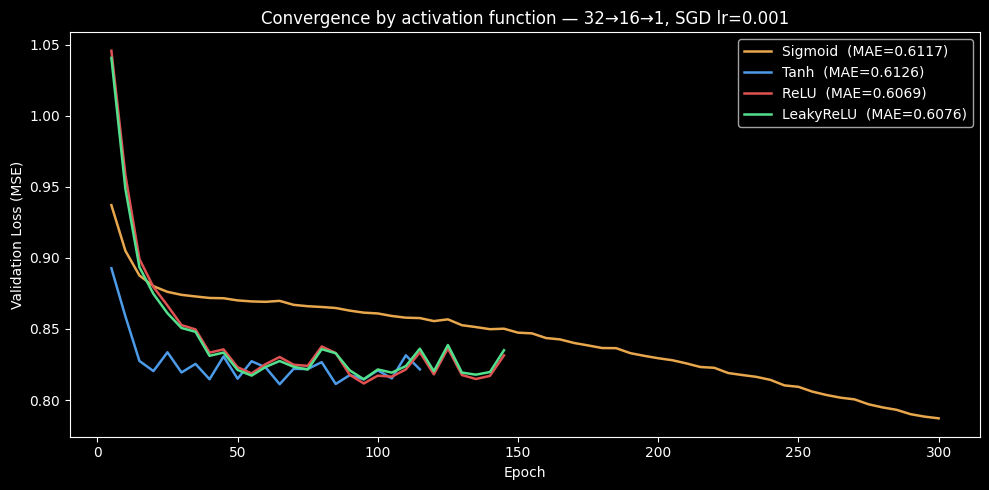

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = {'Sigmoid': '#e8a74c', 'Tanh': '#4c9be8', 'ReLU': '#e05252', 'LeakyReLU': '#52e08c'}

for name, r in results.items():
    epochs_x = [p[0] for p in r['val_losses']]
    losses_y = [p[1] for p in r['val_losses']]
    ax.plot(epochs_x, losses_y, label=f"{name}  (MAE={r['mae']:.4f})",
            color=colors[name], linewidth=1.8)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (MSE)')
ax.set_title('Convergence by activation function — 32→16→1, SGD lr=0.001')
ax.legend()
plt.tight_layout()
plt.show()

**Observations:**

- **Sigmoid** is the slowest to converge by far — still descending at epoch 300 with no early stopping triggered.
  Its gradient vanishes quickly as activations saturate, making weight updates in early layers almost negligible.

- **Tanh, ReLU and LeakyReLU** converge at a similar speed and reach comparable final loss levels (~0.82 MSE).
  The three curves are nearly indistinguishable after epoch 50.

- **ReLU and LeakyReLU** show more oscillations during training. This is expected: ReLU's hard zero cutoff
  creates instability when neurons switch between dead and active states across batches.

- **ReLU vs LeakyReLU**: nearly identical results here. This is because after `StandardScaler`,
  a significant portion of the inputs are negative — ReLU kills those activations entirely,
  while LeakyReLU lets a small gradient through. The fact that their MAE is almost the same (0.6069 vs 0.6076)
  suggests the dying neuron effect is limited on this dataset at this depth.

- The **key takeaway** is that **activation choice directly impacts convergence speed**,
  and that activation must be chosen consistently with both the weight initialization and the data preprocessing.
  ReLU with `StandardScaler` is a risky combination that can silently hurt training (since after scaling returns can become negative).

### 3.2 — Weight Initialization

Same architecture (32→16→1), same optimizer, same seed.
Only the weight initialization changes — how does the starting distribution of weights affect training?

In [28]:
configs_init = {
    'standard':      (ReLU,  'standard'),
    'glorot_normal': (Tanh,  'glorot_normal'),
    'he_normal':     (ReLU,  'he_normal'),
    'he_uniform':    (ReLU,  'he_uniform'),
    'lecun_normal':  (Tanh,  'lecun_normal'),
}

results_init = {}

for name, (ActClass, init) in configs_init.items():
    net = NeuralNetwork(
        layers=[
            Dense(neurons=32, activation=ActClass(), weight_init=init),
            Dense(neurons=16, activation=ActClass(), weight_init=init),
            Dense(neurons=1,  activation=Linear())
        ],
        loss=MeanSquaredError()
    )

    np.random.seed(SEED)
    for layer in net.layers:
        layer.first = True

    optim = SGD(lr=LR)
    setattr(optim, 'net', net)

    val_losses = []
    best_loss = 1e9
    no_imp = 0
    patience = 10
    best_model = None

    for e in range(EPOCHS):
        perm = np.random.permutation(X_train.shape[0])
        X_s, y_s = X_train[perm], y_train[perm]
        for i in range(0, X_s.shape[0], 32):
            net.train_batch(X_s[i:i+32], y_s[i:i+32])
            optim.step()

        if (e + 1) % EVAL_EVERY == 0:
            preds = net.forward(X_test, inference=True)
            loss = float(net.loss.forward(preds, y_test))
            val_losses.append((e + 1, loss))

            if loss < best_loss:
                best_loss = loss
                no_imp = 0
                best_model = deepcopy(net)
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

    final_preds = best_model.forward(X_test)
    mae = float(np.mean(np.abs(final_preds - y_test)))
    results_init[name] = {'mae': mae, 'val_losses': val_losses}
    print(f"{name:<20}  MAE: {mae:.4f}  stopped at epoch {val_losses[-1][0]}")

standard              MAE: 0.6044  stopped at epoch 90
glorot_normal         MAE: 0.6126  stopped at epoch 115
he_normal             MAE: 0.6069  stopped at epoch 145
he_uniform            MAE: 0.6073  stopped at epoch 190
lecun_normal          MAE: 0.6161  stopped at epoch 90


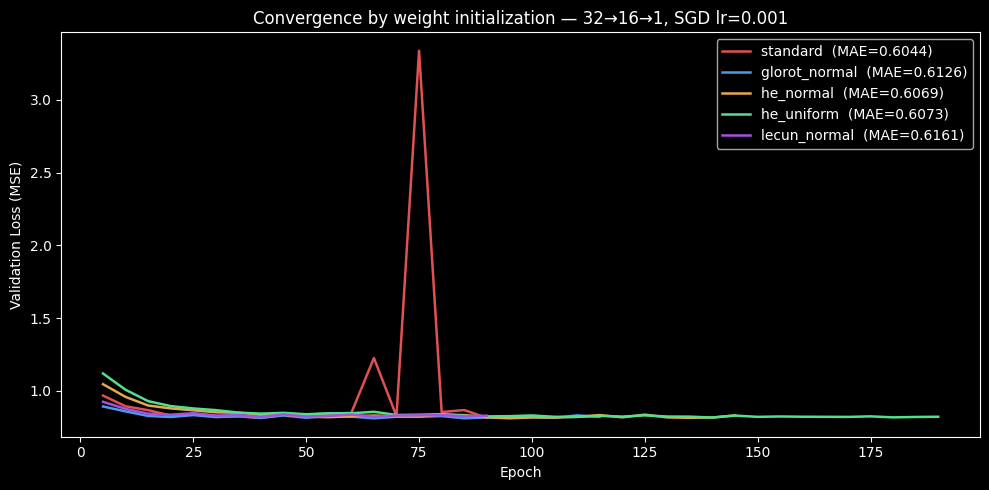

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

colors_init = {
    'standard':      '#e05252',
    'glorot_normal': '#4c9be8',
    'he_normal':     '#e8a74c',
    'he_uniform':    '#52e08c',
    'lecun_normal':  '#a552e0',
}

for name, r in results_init.items():
    epochs_x = [p[0] for p in r['val_losses']]
    losses_y = [p[1] for p in r['val_losses']]
    ax.plot(epochs_x, losses_y, label=f"{name}  (MAE={r['mae']:.4f})",
            color=colors_init[name], linewidth=1.8)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (MSE)')
ax.set_title('Convergence by weight initialization — 32→16→1, SGD lr=0.001')
ax.legend()
plt.tight_layout()
plt.show()

**Observations:**

- **Standard init** causes an exploding gradient around epoch 70 — the loss spikes to ~3.5 before recovering.
  Weights drawn from $N(0,1)$ without scaling produce activations that grow layer by layer,
  eventually causing a catastrophic update. The model recovers here, but this is not guaranteed.

- **He normal and He uniform** (paired with ReLU) are the most stable — smooth descent, no spikes.
  He init scales weights by $\sqrt{2/n_{in}}$, keeping activation variance consistent across layers with ReLU.

- **Glorot normal and LeCun normal** (paired with Tanh) converge smoothly but to a slightly higher loss.
  These initializations are designed for symmetric activations and are not optimal for ReLU.

- The **key takeaway**: initialization is not a minor detail, a wrong choice can cause training instability
  even when everything else is correctly set. Always pair He init with ReLU, and Glorot with Tanh/Sigmoid.

### 3.3 — Optimizer & Learning Rate

Same architecture (32→16→1, ReLU, He init), same seed.
We now look at how the optimizer and learning rate affect training dynamics —
speed of convergence, stability, and ability to escape plateaus.

In [ ]:
configs_optim = {
    'SGD lr=0.0001': SGD(lr=0.0001),
    'SGD lr=0.001': SGD(lr=0.001),
    'SGD lr=0.01': SGD(lr=0.01),
    'SGD momentum=0.9': SGD_MOMENTUM(lr=0.001, momentum=0.9),
    'SGD momentum=0.9 + decay': SGD_MOMENTUM(lr=0.001, final_lr=0.0001, momentum=0.9, decay_type='linear'),
}

results_optim = {}

for name, optim in configs_optim.items():
    net = NeuralNetwork(
        layers=[
            Dense(neurons=32, activation=ReLU(), weight_init='he_normal'),
            Dense(neurons=16, activation=ReLU(), weight_init='he_normal'),
            Dense(neurons=1,  activation=Linear())
        ],
        loss=MeanSquaredError()
    )

    np.random.seed(SEED)
    for layer in net.layers:
        layer.first = True

    setattr(optim, 'net', net)
    optim.max_epochs = EPOCHS
    optim._setup_decay()

    val_losses = []
    best_loss = 1e9
    no_imp = 0
    patience = 10
    best_model = None

    for e in range(EPOCHS):
        perm = np.random.permutation(X_train.shape[0])
        X_s, y_s = X_train[perm], y_train[perm]
        for i in range(0, X_s.shape[0], 32):
            net.train_batch(X_s[i:i+32], y_s[i:i+32])
            optim.step()
        if optim.final_lr is not None:
            optim._decay_lr()

        if (e + 1) % EVAL_EVERY == 0:
            preds = net.forward(X_test, inference=True)
            loss = float(net.loss.forward(preds, y_test))
            val_losses.append((e + 1, loss))

            if loss < best_loss:
                best_loss = loss
                no_imp = 0
                best_model = deepcopy(net)
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

    final_preds = best_model.forward(X_test)
    mae = float(np.mean(np.abs(final_preds - y_test)))
    results_optim[name] = {'mae': mae, 'val_losses': val_losses}
    print(f"{name:<35}  MAE: {mae:.4f}  stopped at epoch {val_losses[-1][0]}")

SGD lr=0.0001                        MAE: 0.6290  stopped at epoch 300
SGD lr=0.001                         MAE: 0.6069  stopped at epoch 145
SGD lr=0.01                          MAE: 0.6184  stopped at epoch 55
SGD momentum=0.9                     MAE: 0.5912  stopped at epoch 55
SGD momentum=0.9 + decay             MAE: 0.5912  stopped at epoch 55


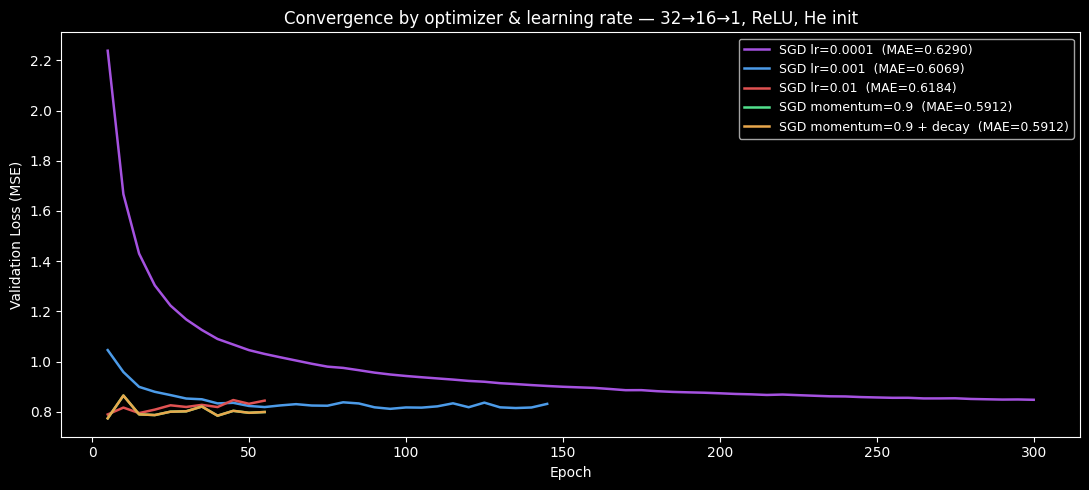

In [31]:
fig, ax = plt.subplots(figsize=(11, 5))

colors_optim = {
    'SGD lr=0.0001':            '#a552e0',
    'SGD lr=0.001':             '#4c9be8',
    'SGD lr=0.01':              '#e05252',
    'SGD momentum=0.9':         '#52e08c',
    'SGD momentum=0.9 + decay': '#e8a74c',
}

for name, r in results_optim.items():
    epochs_x = [p[0] for p in r['val_losses']]
    losses_y = [p[1] for p in r['val_losses']]
    ax.plot(epochs_x, losses_y, label=f"{name}  (MAE={r['mae']:.4f})",
            color=colors_optim[name], linewidth=1.8)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (MSE)')
ax.set_title('Convergence by optimizer & learning rate — 32→16→1, ReLU, He init')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Observations:**

- **lr=0.0001** never converges within 300 epochs — the steps are too small to reach the minimum in time.
- **lr=0.001** converges steadily and reaches a good minimum around epoch 150.
- **lr=0.01** spikes early then recovers, but settles at a worse minimum — the steps overshoot and the model never stabilizes properly.
- **SGD + momentum** converges much faster and reaches a significantly better MAE (0.5912 vs 0.6069).
  The momentum accumulates velocity in consistent directions, allowing the model to slide toward the minimum rather than bouncing around it.
- **momentum + decay** gives identical results here — with early stopping at epoch 55, the decay doesn't have enough time to act. We will see its effect over longer training runs.

momentum=0  MAE: 0.6069
momentum=0.5  MAE: 0.6020
momentum=0.7  MAE: 0.6022
momentum=0.9  MAE: 0.5912
momentum=0.95  MAE: 0.5841
momentum=0.99  MAE: 0.6530


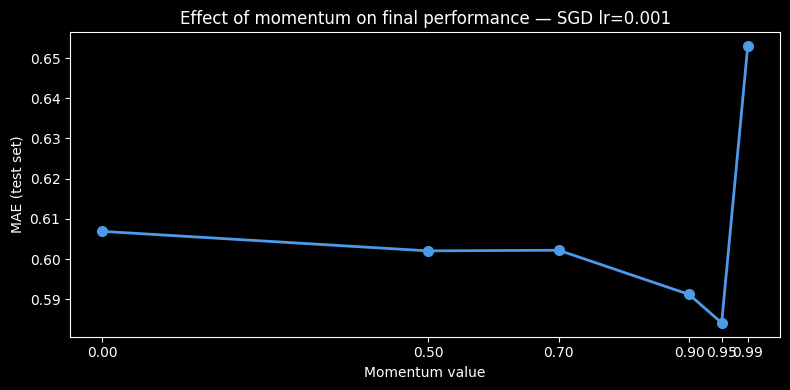

In [32]:
momentum_values = [0, 0.5, 0.7, 0.9, 0.95, 0.99]
momentum_maes = []

for m in momentum_values:
    if m == 0:
        optim = SGD(lr=0.001)
    else:
        optim = SGD_MOMENTUM(lr=0.001, momentum=m)

    net = NeuralNetwork(
        layers=[
            Dense(neurons=32, activation=ReLU(), weight_init='he_normal'),
            Dense(neurons=16, activation=ReLU(), weight_init='he_normal'),
            Dense(neurons=1,  activation=Linear())
        ],
        loss=MeanSquaredError()
    )

    np.random.seed(SEED)
    for layer in net.layers:
        layer.first = True

    setattr(optim, 'net', net)
    optim.max_epochs = EPOCHS
    optim._setup_decay()

    best_loss = 1e9
    no_imp = 0
    patience = 10
    best_model = None

    for e in range(EPOCHS):
        perm = np.random.permutation(X_train.shape[0])
        X_s, y_s = X_train[perm], y_train[perm]
        for i in range(0, X_s.shape[0], 32):
            net.train_batch(X_s[i:i+32], y_s[i:i+32])
            optim.step()

        if (e + 1) % EVAL_EVERY == 0:
            preds = net.forward(X_test, inference=True)
            loss = float(net.loss.forward(preds, y_test))

            if loss < best_loss:
                best_loss = loss
                no_imp = 0
                best_model = deepcopy(net)
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

    final_preds = best_model.forward(X_test)
    mae = float(np.mean(np.abs(final_preds - y_test)))
    momentum_maes.append(mae)
    print(f"momentum={m}  MAE: {mae:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(momentum_values, momentum_maes, marker='o', color='#4c9be8', linewidth=2, markersize=7)
ax.set_xlabel('Momentum value')
ax.set_ylabel('MAE (test set)')
ax.set_title('Effect of momentum on final performance — SGD lr=0.001')
ax.set_xticks(momentum_values)
plt.tight_layout()
plt.show()

**Observations:**

- Performance improves steadily from momentum=0 up to momentum=0.95.
- At momentum=0.99 the MAE collapses — the accumulated velocity is so large that the model overshoots the minimum on every update and never stabilizes.
- There is a clear **sweet spot around 0.9–0.95**: enough inertia to accelerate convergence and escape shallow plateaus, but not so much that the model loses the ability to stop.

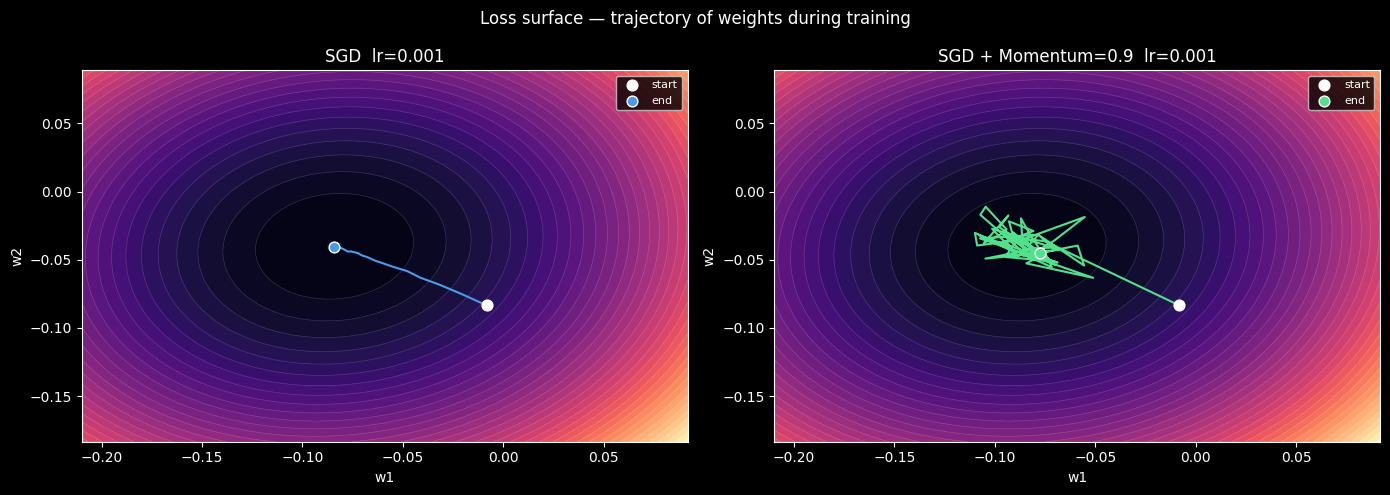

In [36]:
X_2d = X_train[:, :2]
X_2d_test = X_test[:, :2]

def compute_loss_grid(w1_range, w2_range, X, y, n=80):
    W1, W2 = np.meshgrid(np.linspace(*w1_range, n), np.linspace(*w2_range, n))
    Z = np.zeros_like(W1)
    for i in range(n):
        for j in range(n):
            w = np.array([[W1[i,j]], [W2[i,j]]])
            preds = X @ w
            Z[i,j] = float(np.mean((preds - y.reshape(-1,1))**2))
    return W1, W2, Z


def train_and_track(lr, momentum, X, y, epochs=60):
    np.random.seed(SEED)
    W = np.random.randn(2, 1) * 0.1
    b = np.zeros((1, 1))
    velocity = np.zeros_like(W)
    trajectory = [W.copy().flatten()]

    for e in range(epochs):
        perm = np.random.permutation(X.shape[0])
        X_s, y_s = X[perm], y[perm]
        for i in range(0, X_s.shape[0], 32):
            Xb, yb = X_s[i:i+32], y_s[i:i+32].reshape(-1,1)
            preds = Xb @ W + b
            err = preds - yb
            grad_W = Xb.T @ err / len(Xb)
            grad_b = err.mean()
            velocity = momentum * velocity + lr * grad_W
            W -= velocity
            b -= lr * grad_b
        trajectory.append(W.copy().flatten())

    return np.array(trajectory)



traj_sgd = train_and_track(lr=0.001, momentum=0, X=X_2d, y=y_train)
traj_momentum = train_and_track(lr=0.001, momentum=0.9, X=X_2d, y=y_train)

w1_range = (min(traj_sgd[:,0].min(), traj_momentum[:,0].min()) - 0.1, max(traj_sgd[:,0].max(), traj_momentum[:,0].max()) + 0.1)
w2_range = (min(traj_sgd[:,1].min(), traj_momentum[:,1].min()) - 0.1, max(traj_sgd[:,1].max(), traj_momentum[:,1].max()) + 0.1)

W1, W2, Z = compute_loss_grid(w1_range, w2_range, X_2d, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, traj, title, color in zip(
    axes,
    [traj_sgd, traj_momentum],
    ['SGD  lr=0.001', 'SGD + Momentum=0.9  lr=0.001'],
    ['#4c9be8', '#52e08c']
):
    ax.contourf(W1, W2, Z, levels=40, cmap='magma')
    ax.contour(W1, W2, Z, levels=40, colors='white', alpha=0.15, linewidths=0.5)
    ax.plot(traj[:,0], traj[:,1], color=color, linewidth=1.5, zorder=5)
    ax.scatter(traj[0,0], traj[0,1], color='white', s=60, zorder=6, label='start')
    ax.scatter(traj[-1,0], traj[-1,1], color=color, s=60, zorder=6, edgecolors='white', linewidths=1, label='end')
    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Loss surface — trajectory of weights during training', fontsize=12)
plt.tight_layout()
plt.show()

**Loss surface — what actually happens to the weights during training.**

- **SGD** takes large, smooth steps directly toward the minimum, straightforward but slow to escape flat regions.
- **SGD + Momentum** oscillates around the minimum before settling, the accumulated velocity causes slight overshooting,
  visible as the zig-zag pattern near convergence. This is the cost of inertia.
- The key insight: momentum reaches a better region of the loss surface faster,
  even if the path is less clean. The oscillations are a feature, not a bug, they allow the model to escape shallow local minima that would trap plain SGD.

### 3.4 — Weight distributions

We look at what training actually does to the weights inside each layer.
A network that learns should show clearly different weight distributions before and after training.
If the distributions barely move, the gradients are not propagating, the network is not learning.

We compare two configurations: a good one (ReLU + He) and a broken one (Sigmoid + standard init).

ReLU + He init
Validation loss after 10 epochs is 0.779309
No improvement after epoch 20 (1/5), best loss: 0.779309
No improvement after epoch 30 (2/5), best loss: 0.779309
No improvement after epoch 40 (3/5), best loss: 0.779309
No improvement after epoch 50 (4/5), best loss: 0.779309
No improvement after epoch 60 (5/5), best loss: 0.779309
Early stopping triggered. Restoring best model.


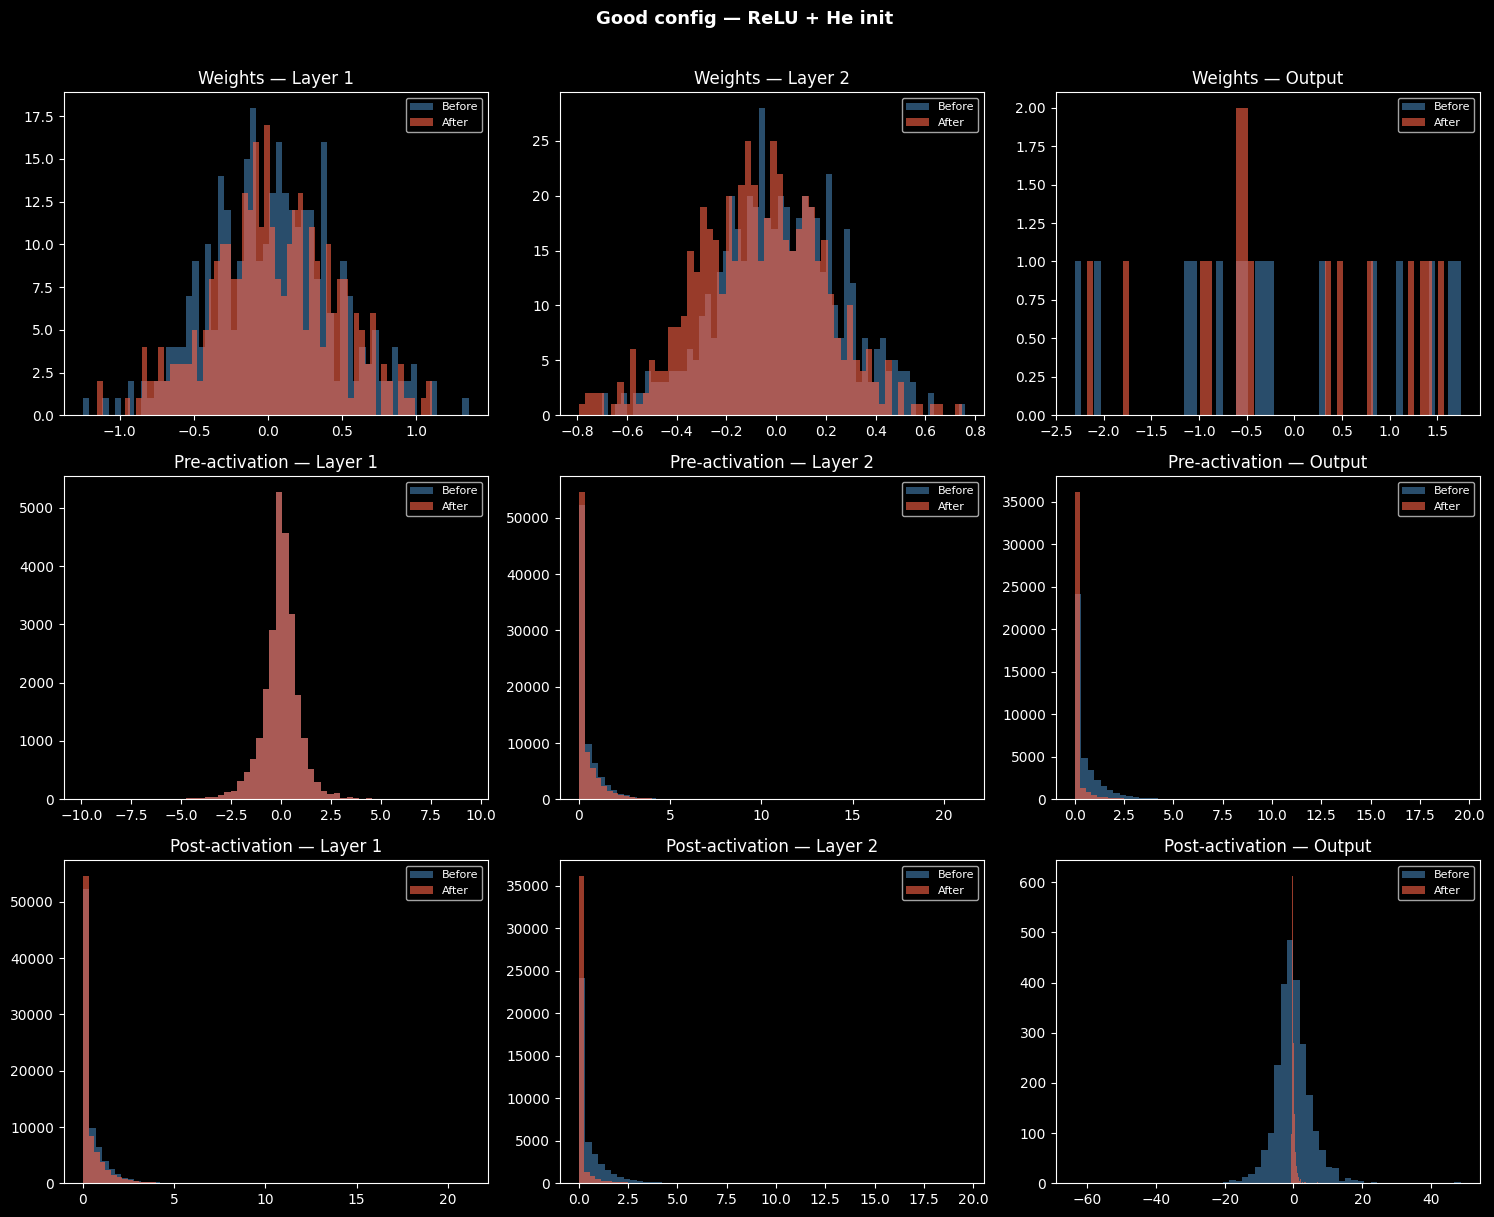

In [ ]:
from model_analysis.Weights_initialization import get_layer_signals, get_weights

def plot_weight_analysis(net, X_train, y_train, X_test, y_test, optimizer, title):
    signals_before = get_layer_signals(net, X_test)
    weights_before = get_weights(net)

    trainer = Trainer(net, optimizer)
    trainer.fit(X_train, y_train, X_test, y_test,
                epochs=300, eval_every=10, seed=201906501, patience=5)

    signals_after = get_layer_signals(net, X_test)
    weights_after = get_weights(net)

    n_layers = len(net.layers)
    fig, axes = plt.subplots(3, n_layers, figsize=(5 * n_layers, 12))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    layer_labels = [f'Layer {i+1}' if i < n_layers-1 else 'Output' for i in range(n_layers)]

    for i in range(n_layers):
        ax = axes[0, i]
        ax.hist(weights_before[i], bins=60, alpha=0.6, label='Before', color='steelblue')
        ax.hist(weights_after[i],  bins=60, alpha=0.6, label='After',  color='tomato')
        ax.set_title(f'Weights — {layer_labels[i]}')
        ax.legend(fontsize=8)

        ax = axes[1, i]
        ax.hist(signals_before[i]['pre_activation'], bins=60, alpha=0.6, label='Before', color='steelblue')
        ax.hist(signals_after[i]['pre_activation'],  bins=60, alpha=0.6, label='After',  color='tomato')
        ax.set_title(f'Pre-activation — {layer_labels[i]}')
        ax.legend(fontsize=8)

        ax = axes[2, i]
        ax.hist(signals_before[i]['post_activation'], bins=60, alpha=0.6, label='Before', color='steelblue')
        ax.hist(signals_after[i]['post_activation'],  bins=60, alpha=0.6, label='After',  color='tomato')
        ax.set_title(f'Post-activation — {layer_labels[i]}')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


print("Good Config: ReLU + He init")
good_net = NeuralNetwork(
    layers=[
        Dense(neurons=32, activation=ReLU(), weight_init='he_normal'),
        Dense(neurons=16, activation=ReLU(), weight_init='he_normal'),
        Dense(neurons=1,  activation=Linear())
    ],
    loss=MeanSquaredError()
)
plot_weight_analysis(good_net, X_train, y_train, X_test, y_test,
                     SGD_MOMENTUM(lr=0.001, momentum=0.9),
                     'Good config — ReLU + He init')

Bad config: Sigmoid + standard init
Validation loss after 10 epochs is 0.871349
Validation loss after 20 epochs is 0.849065
Validation loss after 30 epochs is 0.827167
Validation loss after 40 epochs is 0.815269
Validation loss after 50 epochs is 0.809559
Validation loss after 60 epochs is 0.807283
Validation loss after 70 epochs is 0.801255
Validation loss after 80 epochs is 0.799294
Validation loss after 90 epochs is 0.797884
Validation loss after 100 epochs is 0.795060
No improvement after epoch 110 (1/5), best loss: 0.795060
No improvement after epoch 120 (2/5), best loss: 0.795060
No improvement after epoch 130 (3/5), best loss: 0.795060
No improvement after epoch 140 (4/5), best loss: 0.795060
No improvement after epoch 150 (5/5), best loss: 0.795060
Early stopping triggered. Restoring best model.


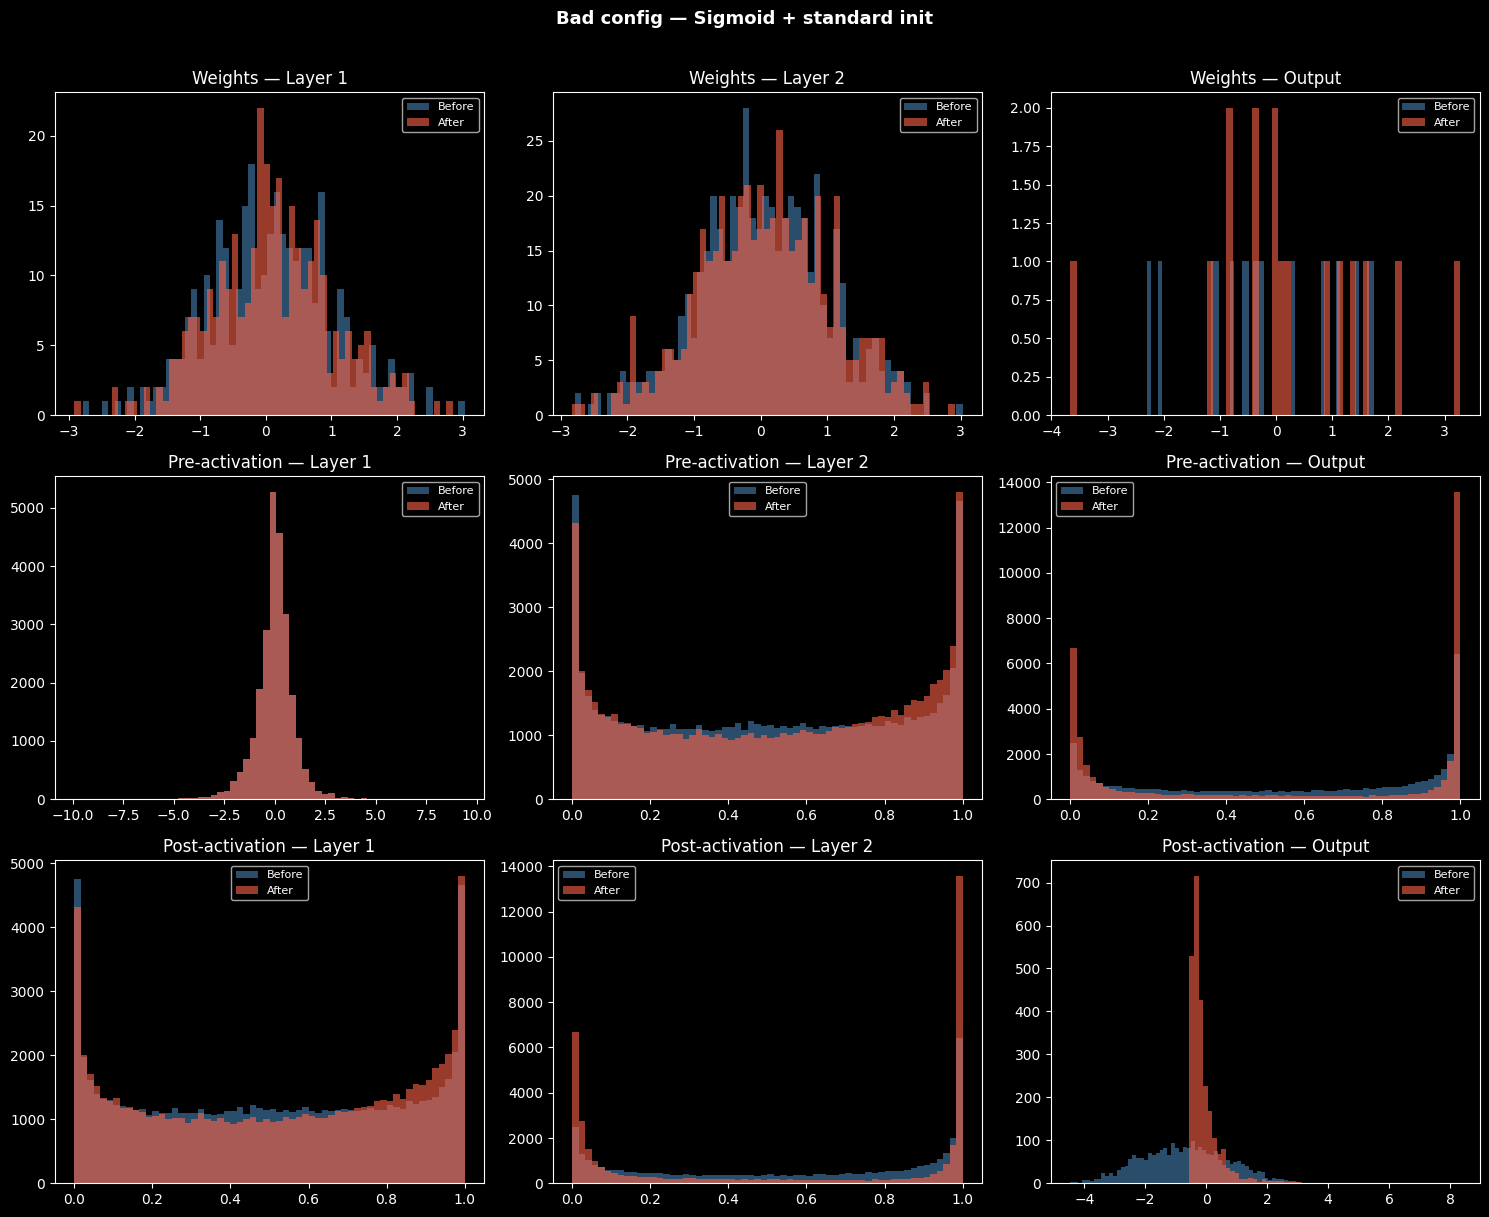

In [40]:
print("Bad config: Sigmoid + standard init")
bad_net = NeuralNetwork(
    layers=[
        Dense(neurons=32, activation=Sigmoid(), weight_init='standard'),
        Dense(neurons=16, activation=Sigmoid(), weight_init='standard'),
        Dense(neurons=1,  activation=Linear())
    ],
    loss=MeanSquaredError()
)
plot_weight_analysis(bad_net, X_train, y_train, X_test, y_test,
                     SGD_MOMENTUM(lr=0.001, momentum=0.9),
                     'Bad config — Sigmoid + standard init')

#### Weight distributions — good config vs broken config

**Weights:** With ReLU + He, weight distributions shift and spread significantly after training — the network actively updates all layers. With Sigmoid + standard init, weights barely move and Before/After distributions almost overlap, gradients are too small to push weights far from initialization.

**Pre-activations:** With ReLU + He, pre-activations spread widely after training (-10 to +10), the network uses the full range of ReLU. With Sigmoid + standard, Layer 1 pre-activations are already large before training, immediately in the saturation zone of Sigmoid. Layer 2 only receives values in [0, 1] from the previous Sigmoid output, a very narrow input range.

**Post-activations:** With ReLU + He, activations are spread and non-trivial — neurons are alive and transmitting information. With Sigmoid + standard, Layer 2 post-activations are entirely compressed between 0.9 and 1.0, all neurons output nearly the same value and the layer transmits no useful information to the output.

**Key takeaway:** Sigmoid saturation cascades through layers — each layer receives an increasingly impoverished signal. This is the vanishing gradient made visible: not just a number, but a distribution collapsing layer by layer.

### 3.5 — Gradient flow

We track the gradient norm per layer during training.
If early layers receive much smaller gradients than the output layer, the network is experiencing vanishing gradients. The first layers are barely learning.

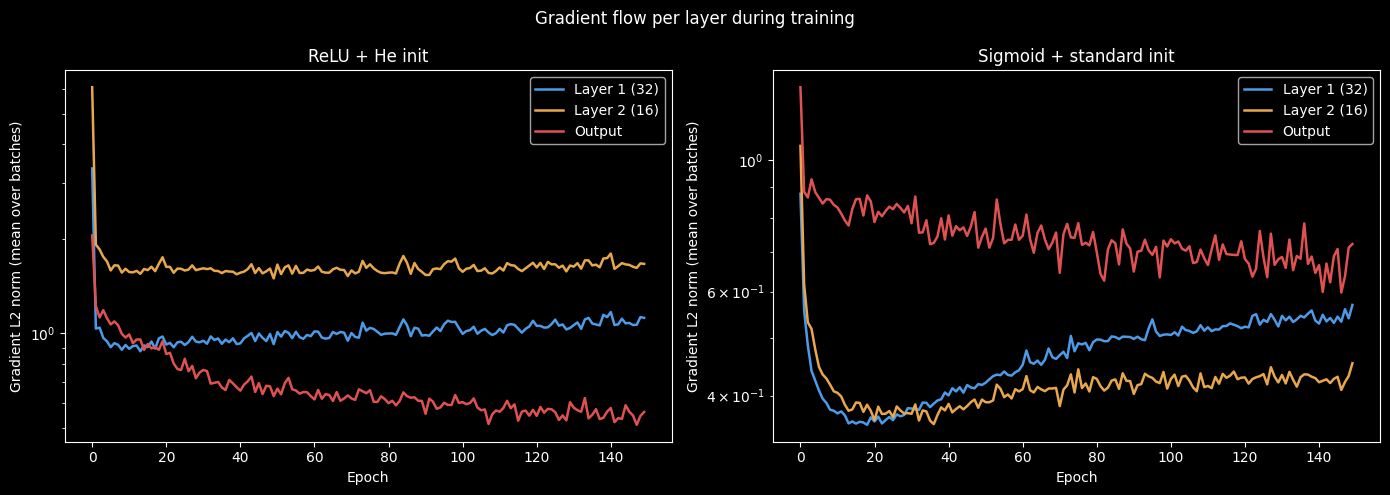

In [41]:
def track_gradient_norms(net, optimizer, X_tr, y_tr, epochs=150):
    np.random.seed(SEED)
    for layer in net.layers:
        layer.first = True
    setattr(optimizer, 'net', net)
    optimizer.max_epochs = epochs
    optimizer._setup_decay()

    _ = net.forward(X_tr[:32])

    n_layers = len(net.layers)
    grad_norms = [[] for _ in range(n_layers)]

    for e in range(epochs):
        perm = np.random.permutation(X_tr.shape[0])
        X_s, y_s = X_tr[perm], y_tr[perm]
        epoch_norms = [[] for _ in range(n_layers)]

        for i in range(0, X_s.shape[0], 32):
            net.train_batch(X_s[i:i+32], y_s[i:i+32])
            for li, layer in enumerate(net.layers):
                if layer.param_grads:
                    epoch_norms[li].append(np.linalg.norm(layer.param_grads[0]))
            optimizer.step()

        for li in range(n_layers):
            if epoch_norms[li]:
                grad_norms[li].append(np.mean(epoch_norms[li]))

    return grad_norms



fig, axes = plt.subplots(1, 2, figsize=(14, 5))
layer_labels = ['Layer 1 (32)', 'Layer 2 (16)', 'Output']
colors_g = ['#4c9be8', '#e8a74c', '#e05252']

configs_grad = [
    ('ReLU + He init',          ReLU,    'he_normal', SGD_MOMENTUM(lr=0.001, momentum=0.9)),
    ('Sigmoid + standard init', Sigmoid, 'standard',  SGD_MOMENTUM(lr=0.001, momentum=0.9)),
]

for ax, (title, ActClass, init, optim) in zip(axes, configs_grad):
    net = NeuralNetwork(
        layers=[
            Dense(neurons=32, activation=ActClass(), weight_init=init),
            Dense(neurons=16, activation=ActClass(), weight_init=init),
            Dense(neurons=1,  activation=Linear())
        ],
        loss=MeanSquaredError()
    )
    grad_norms = track_gradient_norms(net, optim, X_train, y_train)

    for li, (g, lbl) in enumerate(zip(grad_norms, layer_labels)):
        ax.plot(g, label=lbl, color=colors_g[li], linewidth=1.8)

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Gradient L2 norm (mean over batches)')
    ax.set_yscale('log')
    ax.legend()

plt.suptitle('Gradient flow per layer during training', fontsize=12)
plt.tight_layout()
plt.show()

**Gradient flow — ReLU + He vs Sigmoid + standard init.**

With ReLU + He, all three layers maintain gradients in the same order of magnitude throughout training — the signal propagates cleanly from the output back to the first layer. Every layer learns simultaneously.

With Sigmoid + standard init, the output layer receives gradients 2-3x larger than the early layers. The signal weakens as it travels back through the network — Layer 1 is learning significantly slower than the output. This is the vanishing gradient in action.

The gap looks moderate here because the network is shallow (3 layers). On a 10 or 20 layer network, this effect compounds multiplicatively and becomes catastrophic — early layers receive near-zero gradients and stop learning entirely. This is precisely why ReLU became the default activation for deep networks.

### 3.6 — Lag window

The lag defines how many past days the model receives as input.
We test multiple lag values with the best configuration found so far (ReLU, He init, SGD + momentum=0.9).
At what point does adding more past data stop helping?

lag=1    MAE=0.6288
lag=3    MAE=0.5791
lag=5    MAE=0.5883
lag=10   MAE=0.5912
lag=20   MAE=0.6022
lag=30   MAE=0.6076
lag=45   MAE=0.6000
lag=60   MAE=0.6139


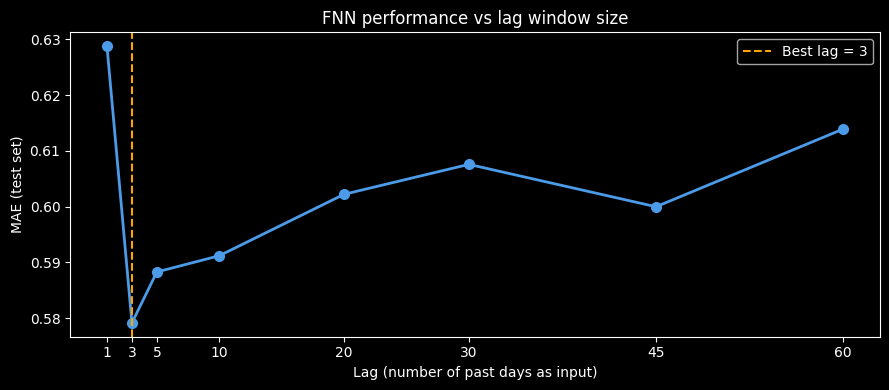


Best lag: 3  MAE: 0.5791


In [44]:
df_raw = pd.read_csv(DATA_PATH, index_col='Date')

lag_values = [1, 3, 5, 10, 20, 30, 45, 60]
lag_mae = []

for lag in lag_values:
    X_l, y_l = build_dataset_abs_returns(df_raw, lag)
    X_l, y_l, _, _ = scale_data(X_l, y_l)
    X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(X_l, y_l, test_size=0.3, random_state=80718)

    net = NeuralNetwork(
        layers=[
            Dense(neurons=32, activation=ReLU(), weight_init='he_normal'),
            Dense(neurons=16, activation=ReLU(), weight_init='he_normal'),
            Dense(neurons=1,  activation=Linear())
        ],
        loss=MeanSquaredError()
    )

    np.random.seed(SEED)
    for layer in net.layers:
        layer.first = True

    optim = SGD_MOMENTUM(lr=0.001, momentum=0.9)
    setattr(optim, 'net', net)
    optim.max_epochs = EPOCHS
    optim._setup_decay()

    best_loss = 1e9
    no_imp = 0
    patience = 10
    best_model = None

    for e in range(EPOCHS):
        perm = np.random.permutation(X_tr_l.shape[0])
        X_s, y_s = X_tr_l[perm], y_tr_l[perm]
        for i in range(0, X_s.shape[0], 32):
            net.train_batch(X_s[i:i+32], y_s[i:i+32])
            optim.step()

        if (e + 1) % EVAL_EVERY == 0:
            preds = net.forward(X_te_l, inference=True)
            loss = float(net.loss.forward(preds, y_te_l))
            if loss < best_loss:
                best_loss = loss
                no_imp = 0
                best_model = deepcopy(net)
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

    final_preds = best_model.forward(X_te_l)
    mae = float(np.mean(np.abs(final_preds - y_te_l)))
    lag_mae.append(mae)
    print(f"lag={lag:<3}  MAE={mae:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lag_values, lag_mae, marker='o', color='#4c9be8', linewidth=2, markersize=7)
ax.set_xlabel('Lag (number of past days as input)')
ax.set_ylabel('MAE (test set)')
ax.set_title('FNN performance vs lag window size')
ax.set_xticks(lag_values)
best_lag = lag_values[int(np.argmin(lag_mae))]
ax.axvline(best_lag, color='orange', linestyle='--', linewidth=1.5, label=f'Best lag = {best_lag}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nBest lag: {best_lag}  MAE: {min(lag_mae):.4f}")

**Observations:**

Performance peaks at lag=3 (MAE=0.5791) then degrades steadily as the window grows.

This is not just overfitting. The FNN assigns an independent weight to each lag but has no mechanism to prioritize recent information over distant information — all lags are treated as equal, unordered features. Adding lags beyond 3-5 days introduces noise that drowns out the useful signal from recent returns.

This reveals a structural limitation: the FNN cannot learn that lag_1 matters more than lag_45. It has no notion of recency or temporal order. A model with memory — like an RNN — could in principle learn to weight recent steps more heavily and capture longer dependencies without this degradation.

We will use lag=3 as the reference configuration for the rest of the section.

### 3.7 — Limitations of the FNN

We now demonstrate empirically what the FNN structurally cannot do.
These are not tuning problems, no choice of hyperparameters can fix them.
They are architectural limitations that motivate the move to recurrent models.

#### 3.7.1 — Order blindness

lag=3    original=0.5791  shuffled=0.5921  gap=0.0130
lag=5    original=0.5883  shuffled=0.6074  gap=0.0192
lag=10   original=0.5912  shuffled=0.5992  gap=0.0080
lag=20   original=0.6022  shuffled=0.6262  gap=0.0240
lag=45   original=0.6000  shuffled=0.6263  gap=0.0263
lag=60   original=0.6139  shuffled=0.6463  gap=0.0323


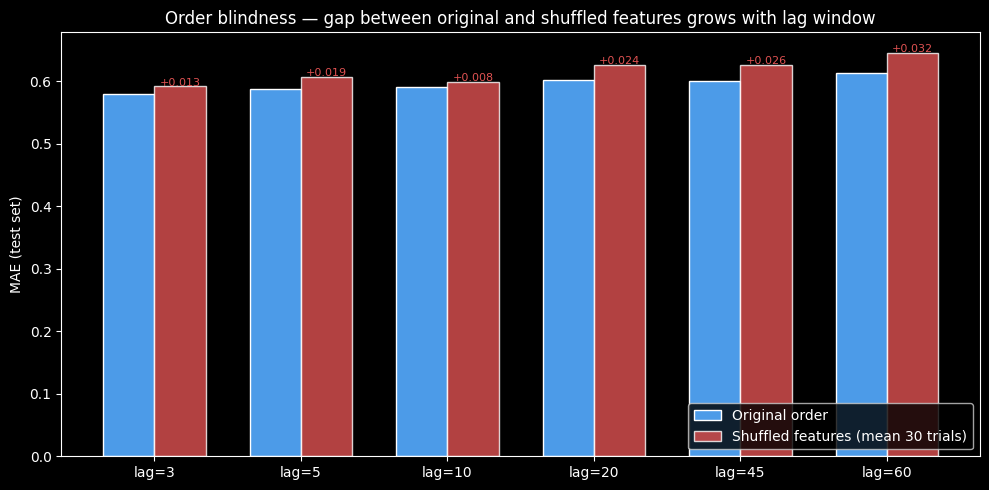

In [47]:
lag_test_values = [3, 5, 10, 20, 45, 60]
mae_original_per_lag = []
mae_shuffled_per_lag = []

for lag in lag_test_values:
    X_l, y_l = build_dataset_abs_returns(df_raw, lag)
    X_l, y_l, _, _ = scale_data(X_l, y_l)
    X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(X_l, y_l, test_size=0.3, random_state=80718)

    net = NeuralNetwork(
        layers=[
            Dense(neurons=32, activation=ReLU(), weight_init='he_normal'),
            Dense(neurons=16, activation=ReLU(), weight_init='he_normal'),
            Dense(neurons=1,  activation=Linear())
        ],
        loss=MeanSquaredError()
    )
    np.random.seed(SEED)
    for layer in net.layers:
        layer.first = True

    optim = SGD_MOMENTUM(lr=0.001, momentum=0.9)
    setattr(optim, 'net', net)
    optim.max_epochs = EPOCHS
    optim._setup_decay()

    best_loss = 1e9
    no_imp = 0
    best_model = None

    for e in range(EPOCHS):
        perm = np.random.permutation(X_tr_l.shape[0])
        X_s, y_s = X_tr_l[perm], y_tr_l[perm]
        for i in range(0, X_s.shape[0], 32):
            net.train_batch(X_s[i:i+32], y_s[i:i+32])
            optim.step()
        if (e + 1) % EVAL_EVERY == 0:
            preds = net.forward(X_te_l, inference=True)
            loss = float(net.loss.forward(preds, y_te_l))
            if loss < best_loss:
                best_loss = loss
                no_imp = 0
                best_model = deepcopy(net)
            else:
                no_imp += 1
                if no_imp >= 10:
                    break

    mae_orig = float(np.mean(np.abs(best_model.forward(X_te_l) - y_te_l)))

    np.random.seed(42)
    shuffled = []
    for _ in range(30):
        col_perm = np.random.permutation(X_te_l.shape[1])
        mae_s = float(np.mean(np.abs(best_model.forward(X_te_l[:, col_perm]) - y_te_l)))
        shuffled.append(mae_s)

    mae_original_per_lag.append(mae_orig)
    mae_shuffled_per_lag.append(np.mean(shuffled))
    print(f"lag={lag:<3}  original={mae_orig:.4f}  shuffled={np.mean(shuffled):.4f}  gap={np.mean(shuffled)-mae_orig:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(lag_test_values))
width = 0.35
bars1 = ax.bar(x - width/2, mae_original_per_lag, width, label='Original order', color='#4c9be8', edgecolor='white')
bars2 = ax.bar(x + width/2, mae_shuffled_per_lag, width, label='Shuffled features (mean 30 trials)', color='#e05252', edgecolor='white', alpha=0.8)

for b1, b2 in zip(bars1, bars2):
    gap = b2.get_height() - b1.get_height()
    ax.text(b2.get_x() + b2.get_width()/2, b2.get_height() + 0.001,
            f'+{gap:.3f}', ha='center', fontsize=8, color='#e05252')

ax.set_xticks(x)
ax.set_xticklabels([f'lag={l}' for l in lag_test_values])
ax.set_ylabel('MAE (test set)')
ax.set_title('Order blindness — gap between original and shuffled features grows with lag window')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**The gap between original and shuffled features grows consistently with the lag window — from +0.013 at lag=3 to +0.032 at lag=60.**

At lag=3, the three input features are temporally close and highly correlated, so there is little order information to destroy. As the window grows, the temporal structure becomes richer — recent returns carry very different information from returns 45 or 60 days ago. Shuffling a 60-lag window completely randomizes this structure, and the model pays a measurable price.

Yet even at lag=60, the gap remains modest (+0.032). This is the core problem: the FNN has learned some implicit ordering through its weights — lag_1 ended up with a larger weight than lag_60 — but this is fragile and inefficient. The model has no architectural guarantee that it will respect temporal order. It stumbled upon it through optimization, and shuffling partially breaks it.

An RNN would not just break — it would be completely unusable with shuffled inputs, because temporal order is not a convention in the data construction, it is the architecture itself.

#### 3.7.2 — Regime blindness

MAE calm regime   (vol < 0.294) : 0.4015  (1876 samples)
MAE crisis regime (vol >= 0.294) : 1.1116  (626 samples)
Crisis/Calm ratio : 2.77x


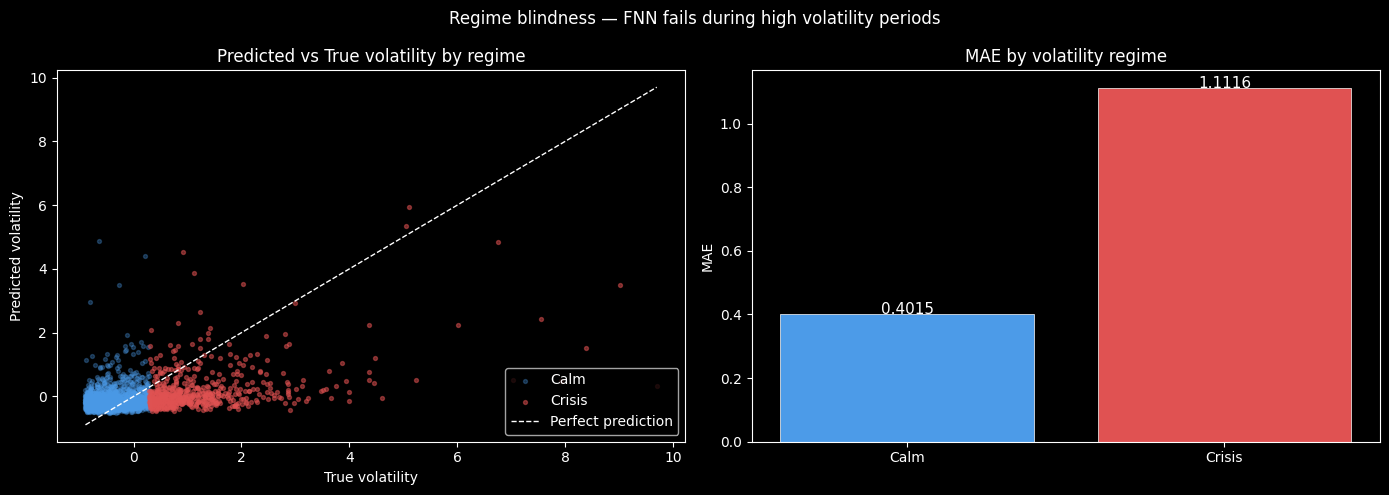

In [50]:
preds_ref = best_model_ref.forward(X_te_l3).flatten()
y_te_flat = y_te_l3.flatten()
errors = np.abs(preds_ref - y_te_flat)

vol_threshold = np.percentile(y_te_flat, 75)
calm_mask = y_te_flat < vol_threshold
crisis_mask = y_te_flat >= vol_threshold

mae_calm = float(np.mean(errors[calm_mask]))
mae_crisis = float(np.mean(errors[crisis_mask]))

print(f"MAE calm regime   (vol < {vol_threshold:.3f}) : {mae_calm:.4f}  ({calm_mask.sum()} samples)")
print(f"MAE crisis regime (vol >= {vol_threshold:.3f}) : {mae_crisis:.4f}  ({crisis_mask.sum()} samples)")
print(f"Crisis/Calm ratio : {mae_crisis/mae_calm:.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_te_flat[calm_mask],   preds_ref[calm_mask],   alpha=0.3, s=8, color='#4c9be8', label='Calm')
ax.scatter(y_te_flat[crisis_mask], preds_ref[crisis_mask], alpha=0.5, s=8, color='#e05252', label='Crisis')
lims = [min(y_te_flat.min(), preds_ref.min()), max(y_te_flat.max(), preds_ref.max())]
ax.plot(lims, lims, '--', color='white', linewidth=1, label='Perfect prediction')
ax.set_xlabel('True volatility')
ax.set_ylabel('Predicted volatility')
ax.set_title('Predicted vs True volatility by regime')
ax.legend(loc='lower right')

ax = axes[1]
ax.bar(['Calm', 'Crisis'], [mae_calm, mae_crisis],
       color=['#4c9be8', '#e05252'], edgecolor='white', linewidth=0.5)
ax.set_ylabel('MAE')
ax.set_title('MAE by volatility regime')
for i, v in enumerate([mae_calm, mae_crisis]):
    ax.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=11)

plt.suptitle('Regime blindness — FNN fails during high volatility periods', fontsize=12)
plt.tight_layout()
plt.show()

**The FNN is nearly **3x worse during crisis periods** (MAE 1.1116) than during calm periods (MAE 0.4015).**

The scatter plot tells the story clearly — during calm periods the model tracks volatility reasonably well,
but during crises the predictions collapse toward low values while true volatility spikes high.
The model systematically **underestimates volatility during the periods that matter most** financially.

This is structural. The FNN makes each prediction independently from a static snapshot of the last 3 returns.
It has no persistent state that accumulates the context of a volatility buildup — no memory of the fact that
the last 3 days were already turbulent. Each prediction starts from scratch.

Volatility clustering means that high volatility today is the best predictor of high volatility tomorrow.
A model without memory cannot exploit this — it sees only the current window, not the regime it is in.
This is exactly what an RNN is designed to capture.

### 3.8 — Weight distribution evolution during training

We snapshot the weight distributions at different moments during training.
This shows concretely how the network transforms its parameters over time — and whether all layers are actively learning.